# Config

In [1]:
import numpy as np
import sys
import pandas as pd

In [2]:
Proj_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/FG_2026_Projections'

In [3]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers'

In [4]:
Player_ID_Map_Path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Player_ID_Map/Latest_Player_ID_Map.csv'

In [5]:
Player_ID_Map_df = pd.read_csv(Player_ID_Map_Path)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].astype(str)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].fillna(Player_ID_Map_df['FG Minor ID'])
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].str.replace('.0','')
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].astype(str)
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].str.replace('.0','')

In [6]:
sys.path.append('../')

In [7]:
Latest_Proj = {
    'Hitter':'Jan23_2026',
    'Pitcher':'Jan23_2026'
}

In [8]:
SGP_Calc_date = 'Jan25_2026'

In [9]:
publish_Val_Update = {
    'Hitter':True,
    'Pitcher':True
}

In [10]:

Hitter_Projections_df = pd.read_csv(f"{Proj_path}/my_Hitter_Proj_{Latest_Proj['Hitter']}.csv")
Pitcher_Projections_df = pd.read_csv(f"{Proj_path}/my_Pitcher_Proj_{Latest_Proj['Pitcher']}.csv")

Hitter_Projections_df['FG ID'] = Hitter_Projections_df['FG ID'].astype(str)
Hitter_Projections_df['FG ID'] = Hitter_Projections_df['FG ID'].str.replace('.0','')
Hitter_Projections_df['Ottoneu ID'] = Hitter_Projections_df['Ottoneu ID'].astype(str)
Hitter_Projections_df['Ottoneu ID'] = Hitter_Projections_df['Ottoneu ID'].str.replace('.0','')
Pitcher_Projections_df['FG ID'] = Pitcher_Projections_df['FG ID'].astype(str)
Pitcher_Projections_df['FG ID'] = Pitcher_Projections_df['FG ID'].str.replace('.0','')
Pitcher_Projections_df['Ottoneu ID'] = Pitcher_Projections_df['Ottoneu ID'].astype(str)
Pitcher_Projections_df['Ottoneu ID'] = Pitcher_Projections_df['Ottoneu ID'].str.replace('.0','')


In [11]:
Hitter_Projections_df.head()

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,RBI,BB,HBP,SF,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,Name
0,10028,CHC,0.0000,1.0000,1.0000,0.0000,0.00000,0.00000,0.000000,0.00000,...,0.00000,0.00000,0.000000,0.000000,0.000169,999.000000,['C'],18048,C,Christian Bethancourt
1,10155,LAA,129.1444,556.3820,472.4704,113.9432,65.56196,19.01020,1.917732,27.45316,...,73.83592,73.21920,6.691312,3.828264,2.320814,214.580002,['OF'],6305,OF,Mike Trout
2,10642,HOU,0.0000,1.0000,1.0000,0.0000,0.00000,0.00000,0.000000,0.00000,...,0.00000,0.00000,0.000000,0.000000,0.001724,999.000000,['C'],9791,C,Carlos Perez
3,10815,ATL,144.9268,627.0208,543.6880,134.1240,90.24152,26.13876,0.992002,16.75172,...,67.43156,69.00872,9.141040,4.581340,1.197811,183.520004,['OF'],13702,OF,Jurickson Profar
4,11477,MIL,142.5496,612.5212,536.5336,137.0560,92.19288,23.32544,1.235164,19.70256,...,71.73596,66.64432,4.782532,3.651592,1.773006,140.289993,['OF'],14893,OF,Christian Yelich


In [12]:
Pitcher_Projections_df[Pitcher_Projections_df['FG ID'].isin([key for key, val in Pitcher_Projections_df['FG ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,W,L,QS,G,GS,SV,HLD,IP,...,HR,BB,HBP,SO,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,Name


In [13]:
Hitter_Projections_df = Hitter_Projections_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
Pitcher_Projections_df = Pitcher_Projections_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [14]:
Hitter_Projections_df[Hitter_Projections_df['Ottoneu ID'].isin([key for key, val in Hitter_Projections_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,RBI,BB,HBP,SF,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,Name


In [15]:
Pitcher_Projections_df[Pitcher_Projections_df['Ottoneu ID'].isin([key for key, val in Pitcher_Projections_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,W,L,QS,G,GS,SV,HLD,IP,...,HR,BB,HBP,SO,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,Name


<Axes: >

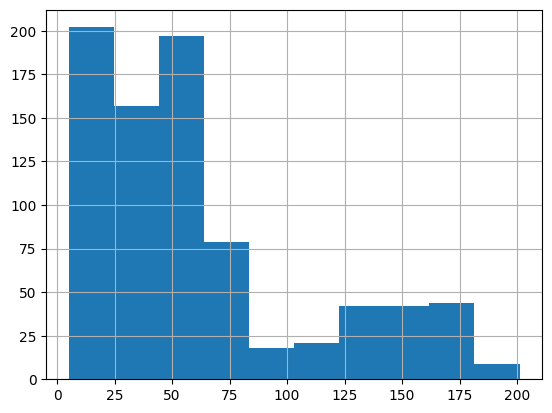

In [16]:
Pitcher_Projections_df[Pitcher_Projections_df['IP'] > 5.]['IP'].hist()

In [17]:

#Filter Pitchers
Pitcher_Projections_df = Pitcher_Projections_df[Pitcher_Projections_df['IP'] > 40.]

#Filter Hitters
Hitter_Projections_df = Hitter_Projections_df[Hitter_Projections_df['AB'] > 100.]

In [18]:
from Stat_modules import OBP,SLG,HR9,ERA,WHIP,TB
Hitter_Projections_df['OBP'] = OBP(Hitter_Projections_df['H'],Hitter_Projections_df['BB'],Hitter_Projections_df['HBP'],Hitter_Projections_df['SF'],Hitter_Projections_df['AB'])
Hitter_Projections_df['TB'] = TB(Hitter_Projections_df['1B'],Hitter_Projections_df['2B'],Hitter_Projections_df['3B'],Hitter_Projections_df['HR'])
Hitter_Projections_df['SLG'] = SLG(Hitter_Projections_df['TB'],Hitter_Projections_df['AB'])
Pitcher_Projections_df['HR9'] = HR9(Pitcher_Projections_df['HR'],Pitcher_Projections_df['IP'])
Pitcher_Projections_df['ERA'] = ERA(Pitcher_Projections_df['ER'],Pitcher_Projections_df['IP'])
Pitcher_Projections_df['WHIP'] = WHIP(Pitcher_Projections_df['BB'],Pitcher_Projections_df['H'],Pitcher_Projections_df['IP'])

In [19]:
#Jan23 2025 Roster totals
Replacement_Level = {
    'C':24,
    '1B':25,
    '2B':27,
    'SS':44,
    '3B':19,
    'OF':89,
    'Util':233,
    'SP':150,
    'RP':65,
    'P':215
}
Replacement_window = {
    'C':5,
    '1B':5,
    '2B':5,
    'SS':5,
    '3B':5,
    'OF':5,
    'Util':5,
    'SP':5,
    'RP':5,
    'P':5
}
Replacement_rank_stat = 'WAR'
Hitting_Pos = [
    'C',
    '1B',
    '2B',
    'SS',
    '3B',
    'OF',
    'Util'
]
Pitching_Pos = [
    'SP',
    'RP',
    'P'
]

All_Pos = Hitting_Pos + Pitching_Pos

In [20]:
#Scoring Categories
Count_Scoring_Categories_Batting = [
    'R',
    'HR'
]
Rate_Scoring_Categories_Batting = [
    'OBP',
    'SLG'
]
Count_Scoring_Categories_Pitching = [
    'SO'
]
Rate_Scoring_Categories_Pitching = [
    "HR9",
    "ERA",
    "WHIP"
]
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
League_budget = Team_budget*Num_teams
Hitter_budget = League_budget*Hitter_sal_split
Pitcher_budget = League_budget*(1.-Hitter_sal_split)
Scoring_Categories_Batting = Count_Scoring_Categories_Batting + Rate_Scoring_Categories_Batting
Scoring_Categories_Pitching = Count_Scoring_Categories_Pitching + Rate_Scoring_Categories_Pitching
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [21]:
Hitter_budget

2544.0

In [22]:
Player_id_cols = [
    'FG ID','Ottoneu ID','Name','Ottoneu Positions','Team'
]
Hitter_Count_Stats = [
    'G','PA','AB','H','1B','2B','3B','HR','R','RBI','BB','HBP','SF','WAR','ADP'
]
Pitcher_Count_Stats = [
    'W', 'L', 'QS', 'G', 'GS', 'SV', 'HLD', 'IP', 'TBF', 'H', 'R', 'ER', 'HR', 'BB', 'HBP', 'SO','WAR','ADP'
]

In [23]:
import json
with open(League_path+'/SGP_Denom_dict.json','r') as f:
    SGP_Denom = json.load(f)

In [24]:
SGP_Denom['SO'] = SGP_Denom['K']

# Replacement Level & Playable Average Stats

C
1B
2B
SS
3B
OF
Util


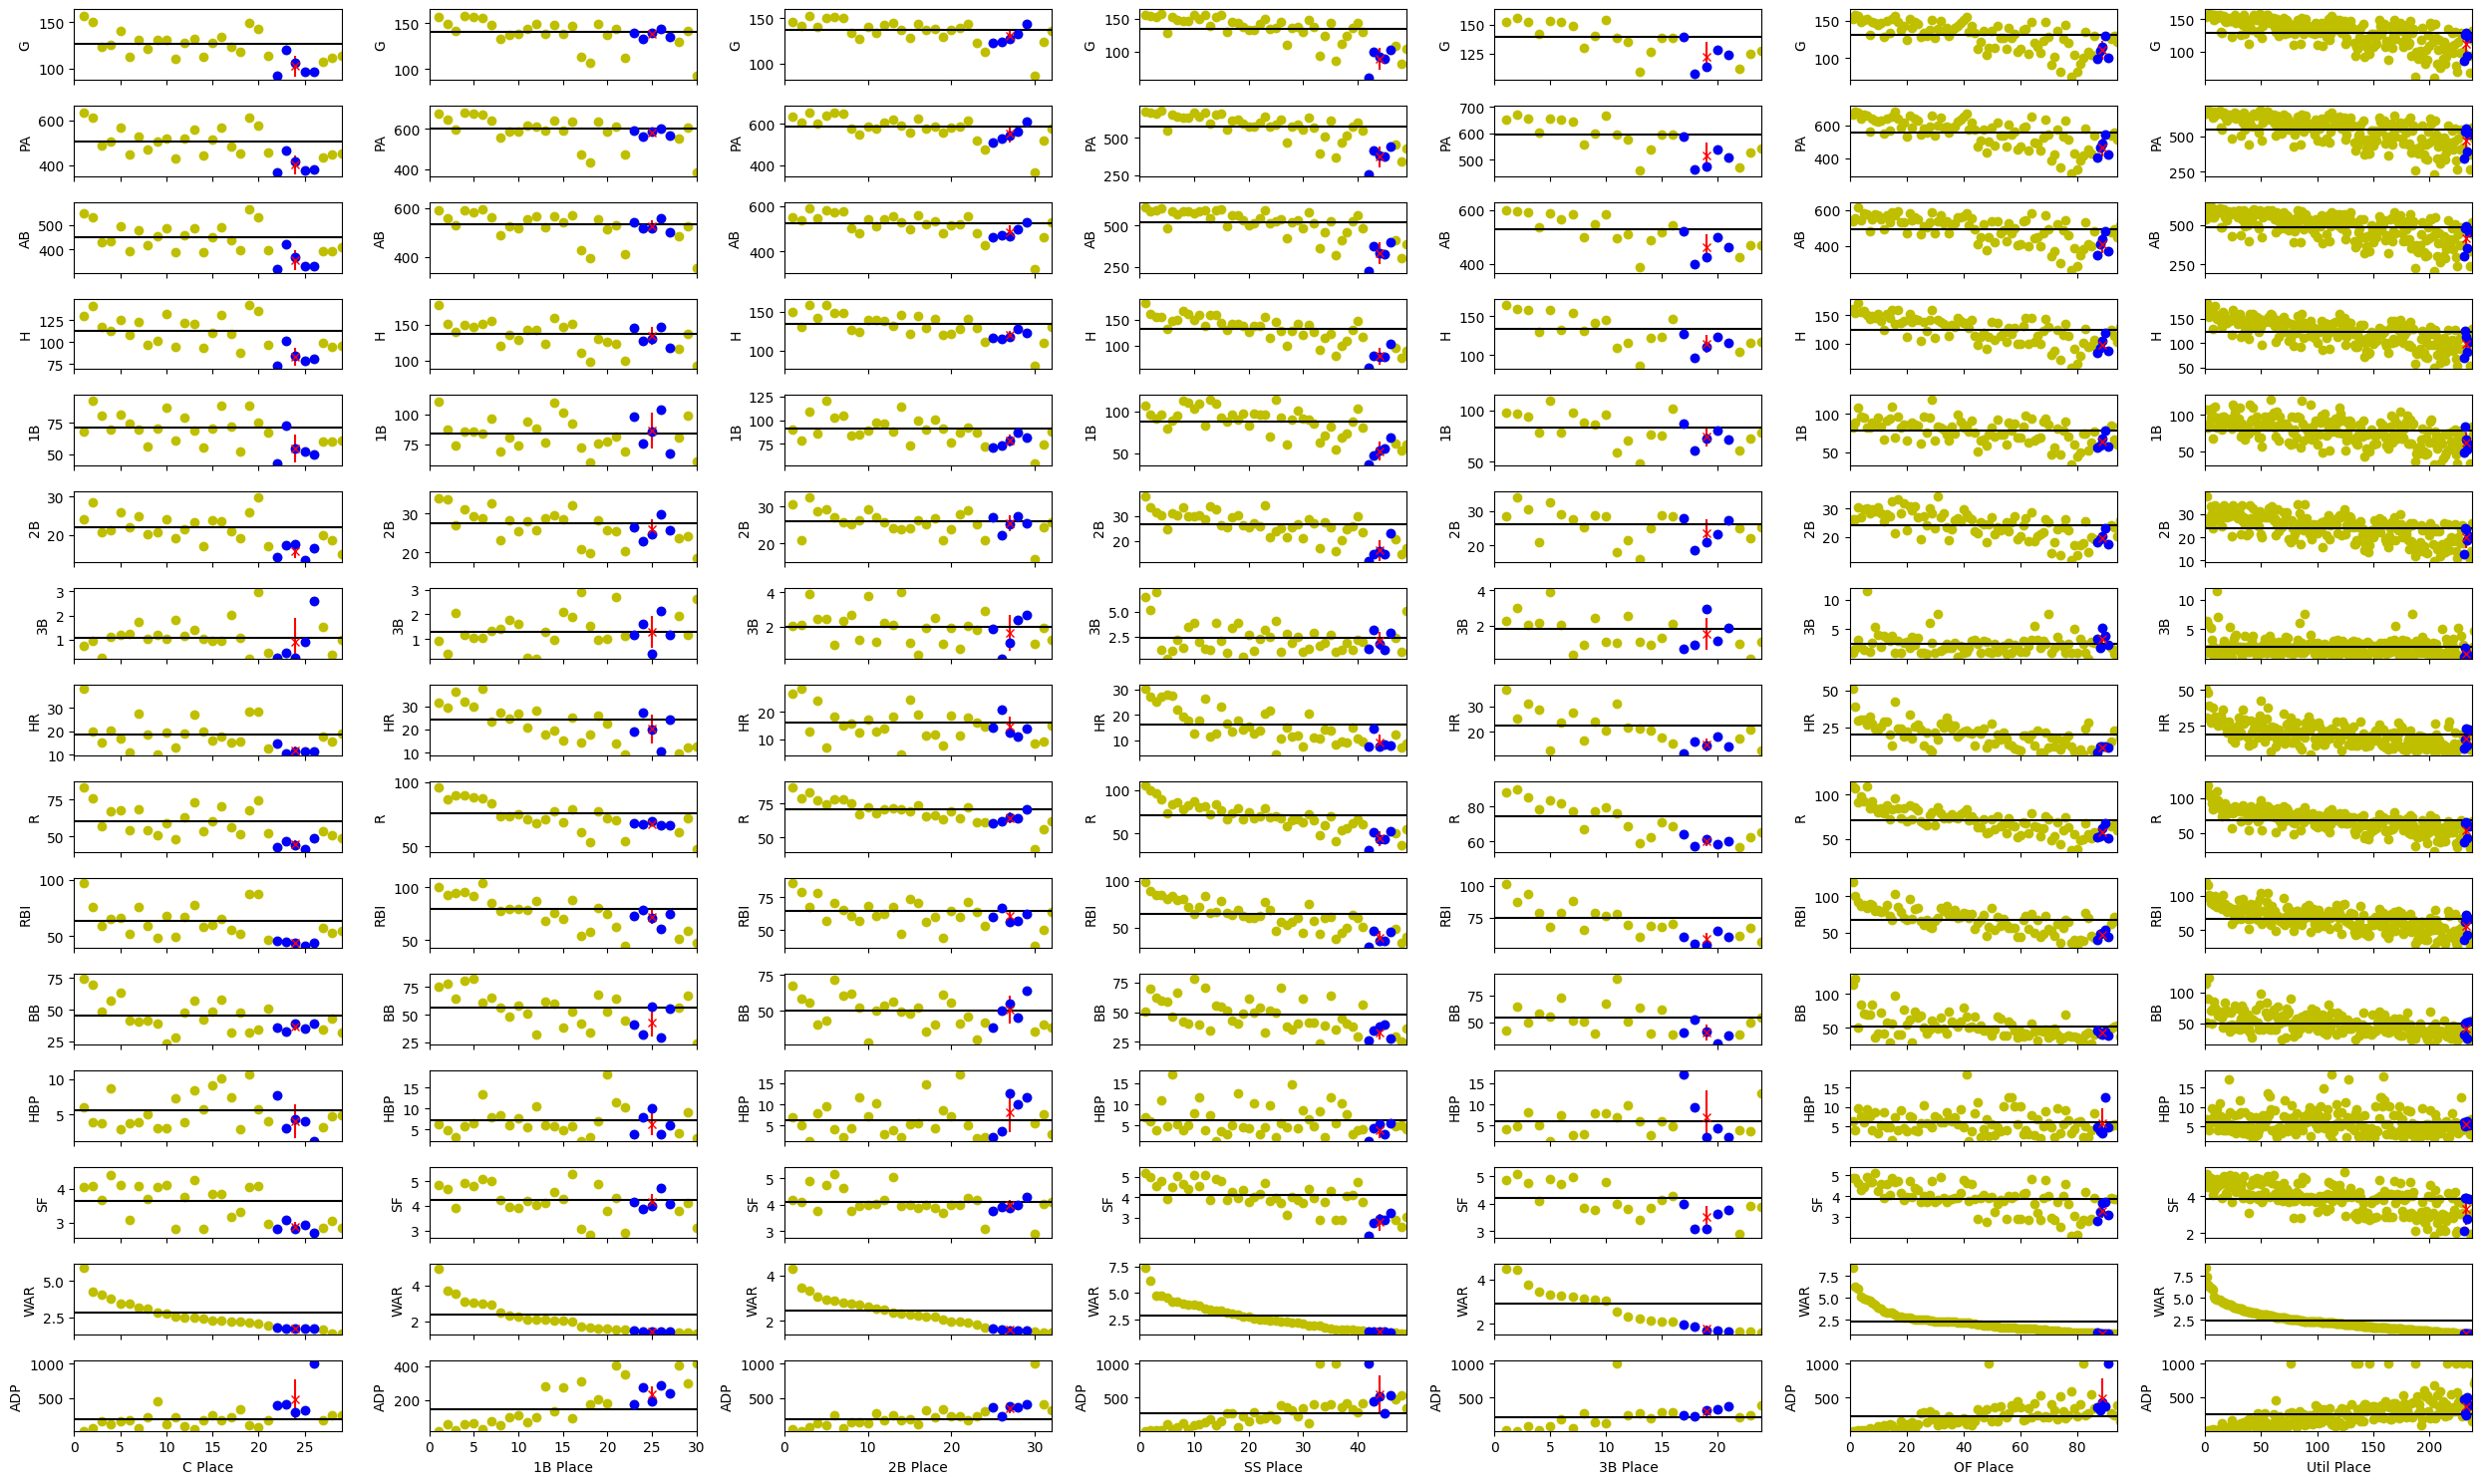

In [25]:
import matplotlib.pyplot as plt
import numpy as np

Hitting_Replacement_Stats_df = pd.DataFrame()
Hitting_Average_Stats_df = pd.DataFrame()

fig, axs = plt.subplots(len(Hitter_Count_Stats),len(Hitting_Pos),figsize=(25,15),sharex='col')
pos_idx = 0
for pos,repl_level_mid in Replacement_Level.items():
    if pos in Pitching_Pos:
        continue
    This_Pos_df = Hitter_Projections_df[Hitter_Projections_df['Ottoneu Positions'].apply(lambda x : f"{pos}" in x.strip('[]').split('/'))]
    if pos == 'Util':
        This_Pos_df = Hitter_Projections_df
    print(pos)
    This_Pos_df['Pos Place'] = This_Pos_df[Replacement_rank_stat].rank(method="dense", ascending=False)
    col_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]


    for col in Hitter_Count_Stats:
        this_axis = axs[col_idx][pos_idx]
        this_axis.plot(This_Pos_df['Pos Place'],This_Pos_df[col], 'yo')

        Replacement_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df['Pos Place'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ]
        mean = Replacement_this_Pos_df[col].mean()
        std = Replacement_this_Pos_df[col].std()
        Hitting_Replacement_Stats_df = pd.concat([
            Hitting_Replacement_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}',
                'mean':mean
            }])
        ])
        this_axis.errorbar(x=[Replacement_this_Pos_df[Replacement_this_Pos_df['Pos Place'] == repl_level_mid]['Pos Place']], y=[mean],yerr=[std], fmt='x',color='r')

        Playable_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] <= repl_level_mid)]
        coef = np.polyfit(Playable_this_Pos_df['Pos Place'],Playable_this_Pos_df[col],1)
        poly1d_fn = np.poly1d(coef) 
        Hitting_Average_Stats_df = pd.concat([
            Hitting_Average_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}',
                'mean':poly1d_fn(repl_level_mid/2)
            }])
        ])
        this_axis.axhline(poly1d_fn(repl_level_mid/2),color='k')

        this_axis.plot(Replacement_this_Pos_df['Pos Place'],Replacement_this_Pos_df[col], 'bo')
        

        this_axis.set_ylabel(col)
        ymin = 0.95*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].min()
        ymax = 1.05*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].max()
        this_axis.set_ylim([ymin,ymax])
        col_idx+=1
    pos_idx+=1
    this_axis.set_xlim([0,x_max])
    this_axis.set_xlabel(f'{pos} Place')
plt.tight_layout()

In [26]:
Hitting_Replacement_Stats_df

,Ottoneu Positions,Stat,mean
0,C,G,102.441272
0,C,PA,400.583120
0,C,AB,355.981520
0,C,H,83.123616
0,C,1B,54.393240
...,...,...,...
0,Util,BB,41.902128
0,Util,HBP,5.638338
0,Util,SF,3.300113
0,Util,WAR,0.929414


In [27]:
Hitting_Average_Stats_df

,Ottoneu Positions,Stat,mean
0,C,G,126.947254
0,C,PA,506.731188
0,C,AB,450.949498
0,C,H,112.597605
0,C,1B,71.000492
...,...,...,...
0,Util,BB,49.395247
0,Util,HBP,5.939831
0,Util,SF,3.864449
0,Util,WAR,2.375342


SP
RP
P


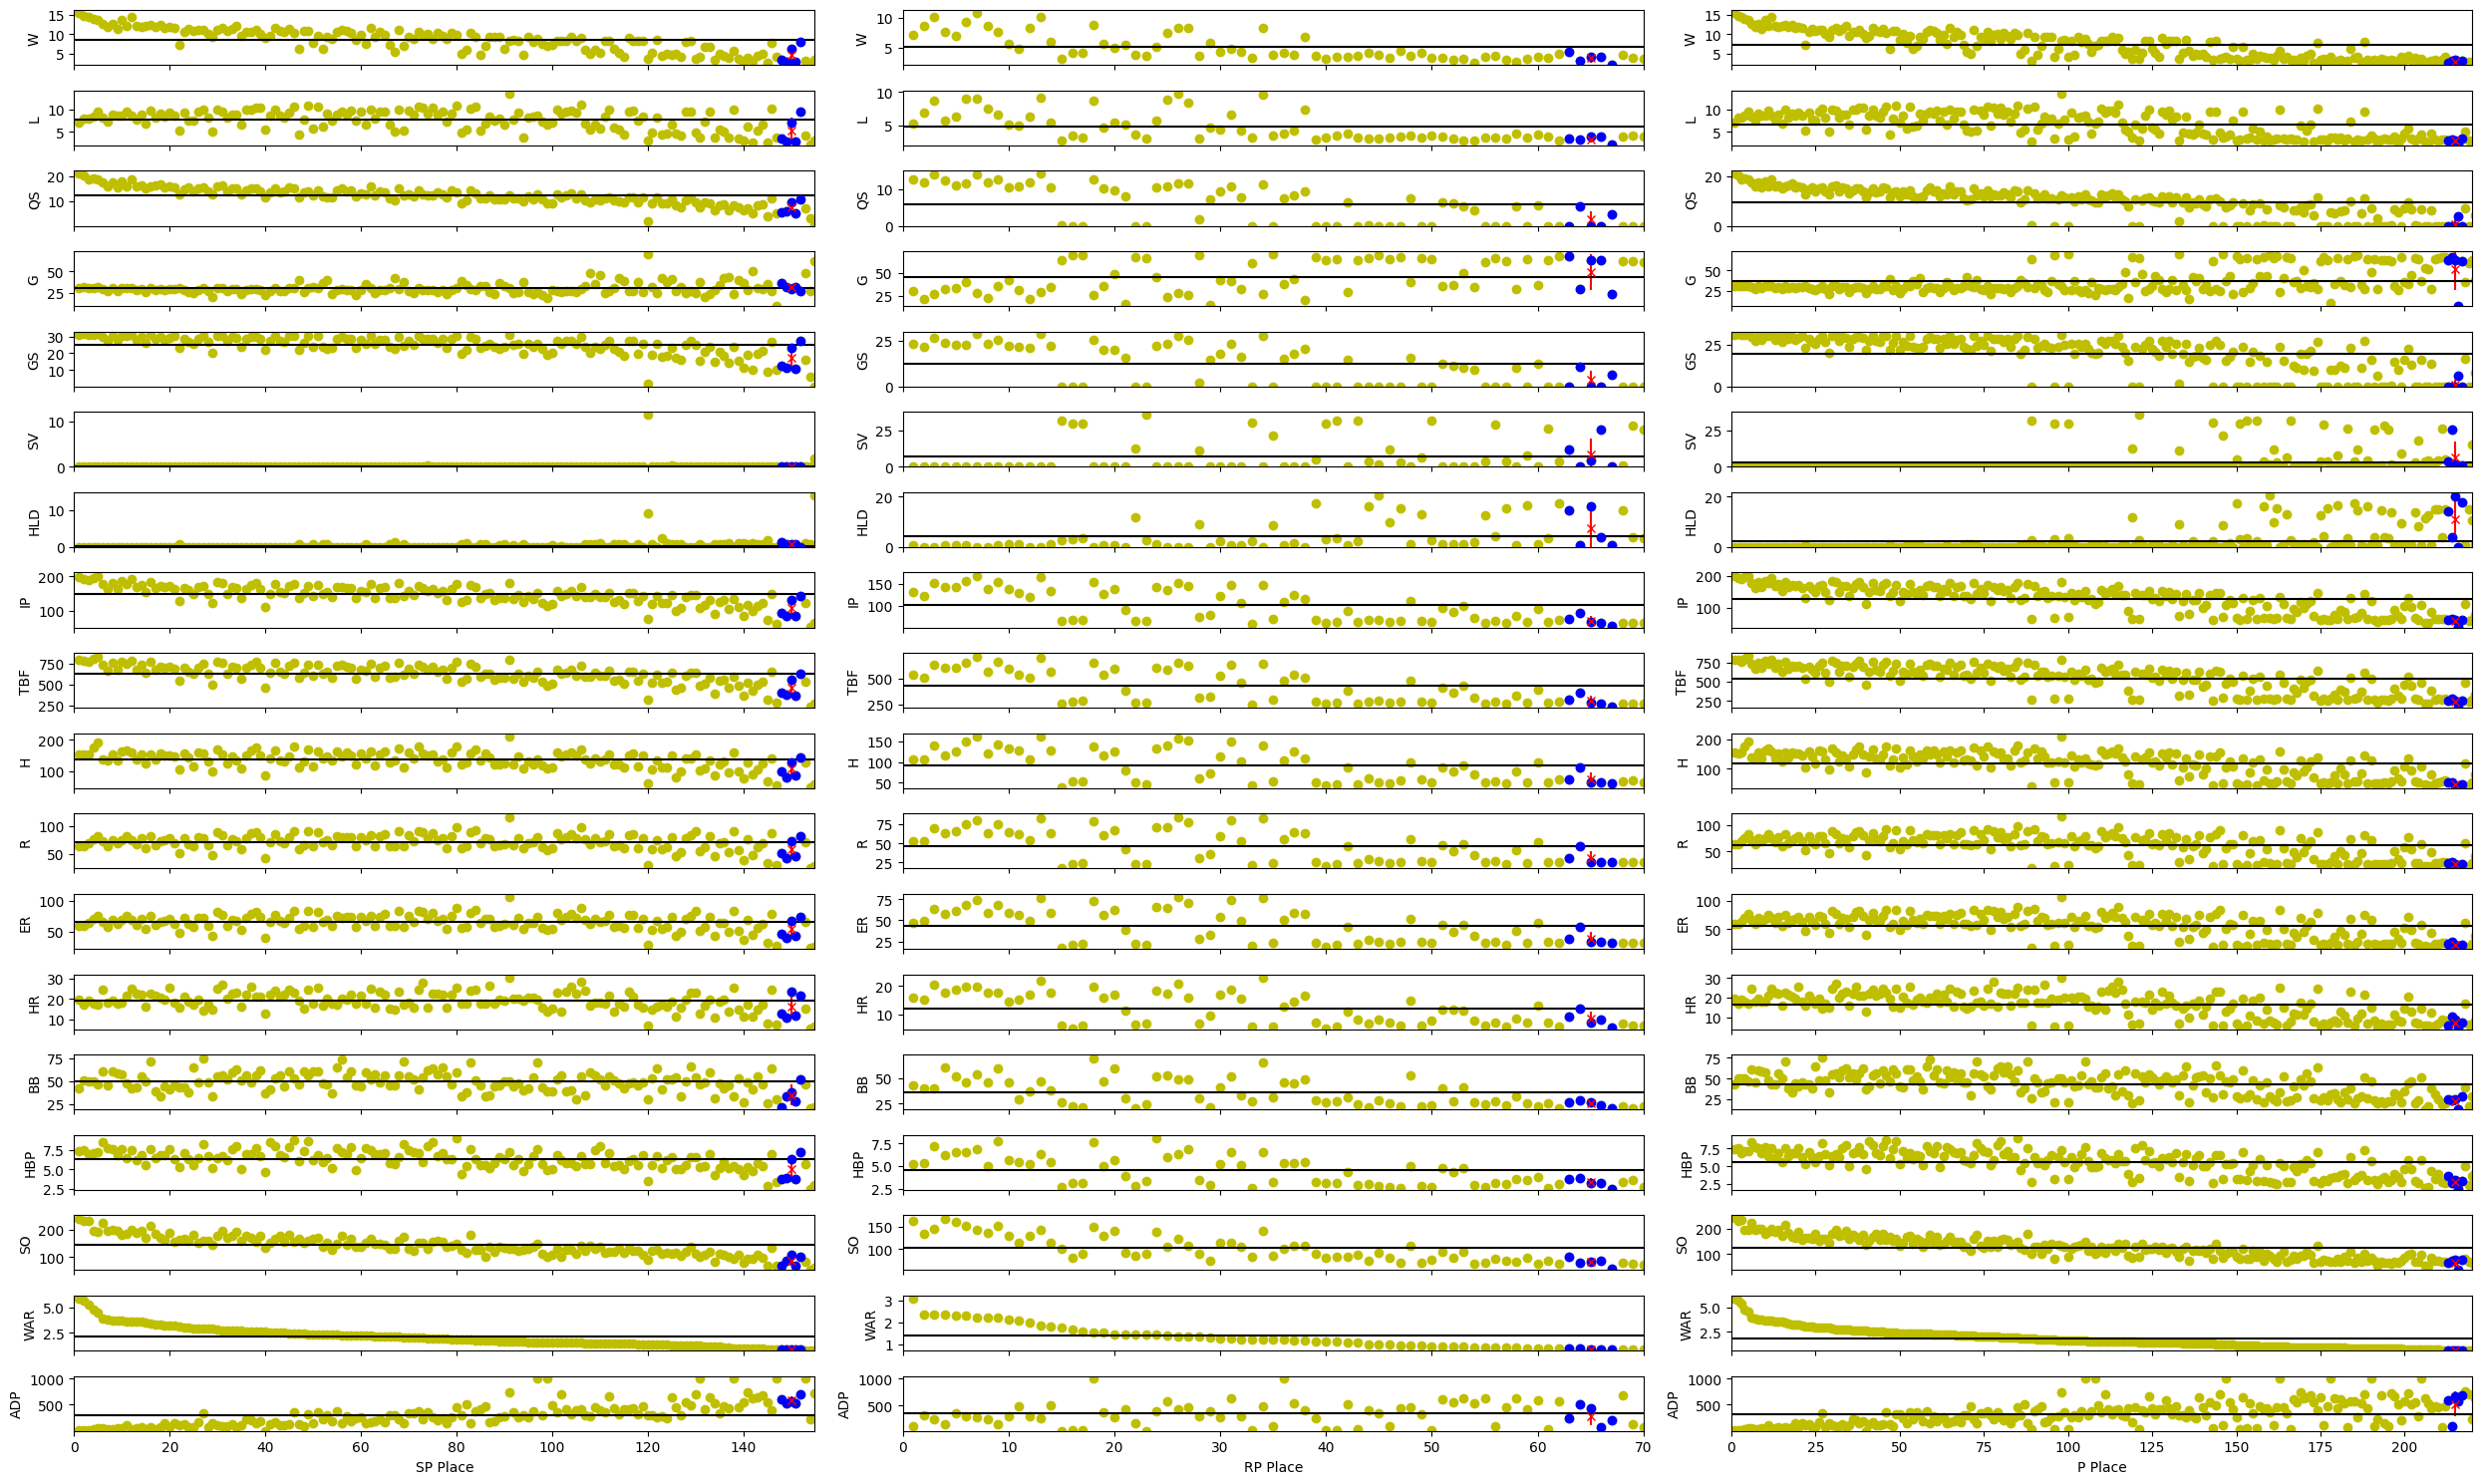

In [28]:
import matplotlib.pyplot as plt
import numpy as np

Pitching_Replacement_Stats_df = pd.DataFrame()
Pitching_Average_Stats_df = pd.DataFrame()

fig, axs = plt.subplots(len(Pitcher_Count_Stats),len(Pitching_Pos),figsize=(25,15),sharex='col')
pos_idx = 0
for pos,repl_level_mid in Replacement_Level.items():
    if pos in Hitting_Pos:
        continue
    This_Pos_df = Pitcher_Projections_df[Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : f"{pos}" in x.strip('[]').split('/'))]
    if pos == 'P':
        This_Pos_df = Pitcher_Projections_df
    print(pos)
    This_Pos_df['Pos Place'] = This_Pos_df[Replacement_rank_stat].rank(method="dense", ascending=False)
    col_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]


    for col in Pitcher_Count_Stats:
        this_axis = axs[col_idx][pos_idx]
        this_axis.plot(This_Pos_df['Pos Place'],This_Pos_df[col], 'yo')

        Replacement_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df['Pos Place'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ]
        mean = Replacement_this_Pos_df[col].mean()
        std = Replacement_this_Pos_df[col].std()
        Pitching_Replacement_Stats_df = pd.concat([
            Pitching_Replacement_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}',
                'mean':mean,
                'std':std
            }])
        ])
        this_axis.errorbar(x=[Replacement_this_Pos_df[Replacement_this_Pos_df['Pos Place'] == repl_level_mid]['Pos Place']], y=[mean],yerr=[std], fmt='x',color='r')

        Playable_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] <= repl_level_mid)]
        coef = np.polyfit(Playable_this_Pos_df['Pos Place'],Playable_this_Pos_df[col],1)
        poly1d_fn = np.poly1d(coef) 
        Pitching_Average_Stats_df = pd.concat([
            Pitching_Average_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}',
                'mean':poly1d_fn(repl_level_mid/2)
            }])
        ])
        this_axis.axhline(poly1d_fn(repl_level_mid/2),color='k')

        this_axis.plot(Replacement_this_Pos_df['Pos Place'],Replacement_this_Pos_df[col], 'bo')
        

        this_axis.set_ylabel(col)
        ymin = 0.95*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].min()
        ymax = 1.05*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].max()
        this_axis.set_ylim([ymin,ymax])
        col_idx+=1
    pos_idx+=1
    this_axis.set_xlim([0,x_max])
    this_axis.set_xlabel(f'{pos} Place')
plt.tight_layout()

In [29]:
Pitching_Replacement_Stats_df

,Ottoneu Positions,Stat,mean,std
0,SP,W,4.682026,2.354735
0,SP,L,5.259526,2.963242
0,SP,QS,7.519346,2.605575
0,SP,G,31.622184,3.414143
0,SP,GS,17.090272,7.686561
0,SP,SV,0.004815,0.010766
0,SP,HLD,0.731302,0.448842
0,SP,IP,107.851744,26.882546
0,SP,TBF,463.388480,119.002671
0,SP,H,108.171056,27.879340


In [30]:
Pitching_Average_Stats_df

,Ottoneu Positions,Stat,mean
0,SP,W,8.647310
0,SP,L,7.794503
0,SP,QS,12.345017
0,SP,G,30.345787
0,SP,GS,24.944388
0,SP,SV,0.082973
0,SP,HLD,0.337107
0,SP,IP,148.240793
0,SP,TBF,626.298783
0,SP,H,136.892364


# Calc Raw SGP

In [31]:
Rate_Scoring_Categories_Batting

['OBP', 'SLG']

In [32]:
Rate_Scoring_Categories_Pitching

['HR9', 'ERA', 'WHIP']

In [33]:
SGP_Denom

{'R': 25.28251748251743,
 'HR': 11.508403361344515,
 'OBP': 0.002503279720279701,
 'SLG': 0.00528697202797202,
 'K': 47.5227326545109,
 'HR9': -0.026016417074877514,
 'ERA': -0.08937283374192077,
 'WHIP': -0.017438135920127117,
 'SO': 47.5227326545109}

In [34]:
for stat in Count_Scoring_Categories_Batting:
    Hitter_Projections_df[f'{stat}_SGP_raw'] = Hitter_Projections_df[stat]/SGP_Denom[stat]

In [35]:
for stat in Count_Scoring_Categories_Pitching:
    Pitcher_Projections_df[f'{stat}_SGP_raw'] = Pitcher_Projections_df[stat]/SGP_Denom[stat]

In [36]:
Hitting_Replacement_Stats_df.pivot_table('mean','Ottoneu Positions','Stat').reset_index()

Stat,Ottoneu Positions,1B,2B,3B,AB,ADP,BB,G,H,HBP,HR,PA,R,RBI,SF,WAR
0,1B,86.236216,25.893128,1.290731,526.57392,233.006000,42.975880,137.871040,133.628880,6.408196,20.208816,581.48824,67.185072,71.281104,4.157530,1.469128
1,2B,78.184096,25.503712,1.621655,485.98040,348.915997,50.664192,130.124240,119.750800,8.061423,14.561344,550.42160,64.370024,60.321640,3.975922,1.609192
2,3B,74.526048,23.578152,1.508494,460.77960,290.091995,40.904536,122.267200,114.873448,7.084581,14.900736,513.95312,60.015544,58.293928,3.511247,1.773587
3,C,54.393240,15.773840,0.897672,355.98152,479.438000,36.384608,102.441272,83.123616,4.096947,11.818872,400.58312,44.563976,43.879256,2.870915,1.711543
4,OF,63.926152,19.605192,3.348512,410.88360,488.942004,42.009872,110.628000,97.788904,5.796318,11.029041,464.09664,56.994336,47.020368,3.317722,0.982611
5,SS,52.489288,16.078944,2.063161,333.36664,549.283997,33.024080,88.749120,79.725640,3.900200,9.214279,374.29224,44.296264,38.857616,2.778590,1.288699
6,Util,62.321040,19.859248,0.859891,415.14384,369.806000,41.902128,111.244352,98.999504,5.638338,16.079319,466.87376,53.564856,55.538896,3.300113,0.929414


In [37]:
Hitting_Average_Stats_df.pivot_table('mean','Ottoneu Positions','Stat')

Stat,1B,2B,3B,AB,ADP,BB,G,H,HBP,HR,PA,R,RBI,SF,WAR
Ottoneu Positions,,,,,,,,,,,,,,,
1B,84.374097,27.378724,1.305486,531.519106,145.507538,56.784189,141.011688,137.036948,7.302766,24.116879,600.623073,75.303559,78.992556,4.250037,2.374885
2B,90.632078,26.107982,1.975901,524.336165,193.309753,49.964540,137.514129,134.477698,6.316185,15.911414,586.564265,70.876844,64.203906,4.122281,2.475327
3B,83.746095,26.058423,1.798856,529.372872,199.900289,54.762271,139.063092,133.806908,6.090565,22.261967,595.395852,74.225063,74.329005,4.227543,2.926552
C,71.000492,21.868358,1.063768,450.949498,182.214423,45.573814,126.947254,112.597605,5.591575,18.669950,506.731188,60.452751,63.108264,3.645179,2.845670
OF,77.794669,24.279276,2.565005,492.969043,219.061541,51.917980,130.376171,124.445009,6.001568,19.839238,555.965594,71.108962,67.259658,3.884208,2.323995
SS,88.144597,26.509950,2.339486,517.509670,260.285570,48.166370,135.478170,133.044987,6.318093,16.104641,578.000825,71.002435,64.414184,4.089219,2.886496
Util,77.985938,24.101721,1.984328,486.770398,244.648167,49.395247,129.484027,122.815174,5.939831,18.812509,547.187412,67.825274,65.663723,3.864449,2.375342


In [38]:
rest_of_roster_df = Hitting_Average_Stats_df[Hitting_Average_Stats_df['Ottoneu Positions'] == 'Util']
full_roster_df = Hitting_Average_Stats_df[Hitting_Average_Stats_df['Ottoneu Positions'] == 'Util']

In [39]:
rest_of_roster_df['rest_of_roster_count'] = (Replacement_Level['Util']/Num_teams)-1.
full_roster_df['full_roster_count'] = (Replacement_Level['Util']/Num_teams)

In [40]:
rest_of_roster_df['rest_of_roster'] = rest_of_roster_df['rest_of_roster_count']*rest_of_roster_df['mean']
full_roster_df['full_roster'] = full_roster_df['full_roster_count']*full_roster_df['mean']

In [41]:
rest_of_roster_stats = rest_of_roster_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_stats = full_roster_df.pivot_table('full_roster','Ottoneu Positions','Stat')

In [42]:
rest_of_roster_stats['H'].values[0]

np.float64(2261.846113079625)

In [43]:
full_roster_stats['H'].values[0]

np.float64(2384.66128664051)

In [44]:
full_roster_OBP = OBP(
        full_roster_stats['H'].values[0],
        full_roster_stats['BB'].values[0],
        full_roster_stats['HBP'].values[0],
        full_roster_stats['SF'].values[0],
        full_roster_stats['AB'].values[0]
    ) 

In [45]:
Hitter_Projections_df['OBP_SGP_raw'] = (
    OBP(
        (Hitter_Projections_df['H']+rest_of_roster_stats['H'].values[0]),
        (Hitter_Projections_df['BB']+rest_of_roster_stats['BB'].values[0]),
        (Hitter_Projections_df['HBP']+rest_of_roster_stats['HBP'].values[0]),
        (Hitter_Projections_df['SF']+rest_of_roster_stats['SF'].values[0]),
        (Hitter_Projections_df['AB']+rest_of_roster_stats['AB'].values[0])) \
    - full_roster_OBP) / SGP_Denom['OBP']

In [46]:
rest_of_roster_TB = TB(
    rest_of_roster_stats['1B'].values[0],
    rest_of_roster_stats['2B'].values[0],
    rest_of_roster_stats['3B'].values[0],
    rest_of_roster_stats['HR'].values[0])
full_roster_TB = TB(
    full_roster_stats['1B'].values[0],
    full_roster_stats['2B'].values[0],
    full_roster_stats['3B'].values[0],
    full_roster_stats['HR'].values[0])
full_roster_SLG = SLG(full_roster_TB,full_roster_stats['AB'].values[0])
Hitter_Projections_df['SLG_SGP_raw'] = (
    SLG(
        (Hitter_Projections_df['TB']+rest_of_roster_TB),
        (Hitter_Projections_df['AB']+rest_of_roster_stats['AB'].values[0])) \
    -  full_roster_SLG) / SGP_Denom['SLG']

In [47]:
Hitter_Projections_df['TOTAL_SGP_raw'] = Hitter_Projections_df[[f'{col}_SGP_raw' for col in Scoring_Categories_Batting]].sum(axis=1)

In [48]:
Hitter_Projections_df.sort_values('TOTAL_SGP_raw',ascending=False).head(10)

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,Name,OBP,TB,SLG,Pos Place,R_SGP_raw,HR_SGP_raw,OBP_SGP_raw,SLG_SGP_raw,TOTAL_SGP_raw
58,15640,NYY,153.0252,662.0624,537.9496,160.6180,82.23712,26.07132,0.990708,51.31892,...,Aaron Judge,0.422946,342.627564,0.636914,1.0,4.347273,4.459256,2.385945,2.257752,13.450226
168,19755,LAD,154.5648,675.7600,576.2060,164.7624,82.63564,28.28560,5.875840,48.56516,...,Shohei Ohtani,0.384457,351.095000,0.609322,3.0,4.683078,4.219974,1.462940,2.093433,12.459425
199,20123,NYM,157.9752,684.2876,552.7056,154.5760,88.31900,26.26024,1.757820,38.83908,...,Juan Soto,0.411102,301.469260,0.545443,4.0,4.246365,3.374845,2.158754,1.311348,11.091312
161,19611,TOR,156.3660,676.0260,588.6444,176.8876,110.61760,33.92332,0.942221,31.40452,...,Vladimir Guerrero Jr.,0.382989,306.908984,0.521383,9.0,3.792140,2.728834,1.425012,1.110955,9.056940
69,16478,PHI,156.7548,678.8604,568.5348,134.0504,68.59052,21.27832,0.991106,42.59028,...,Kyle Schwarber,0.352638,284.481599,0.500377,50.0,3.816012,3.700798,0.664978,0.838318,9.020107
116,18401,ATL,148.1860,642.1740,545.0952,156.0124,96.97876,26.76368,2.097344,30.17248,...,Ronald Acuña Jr.,0.386985,277.488072,0.509064,8.0,3.878981,2.621778,1.454269,0.899916,8.854943
374,25764,KCR,156.0036,674.3132,610.9472,182.2136,107.51320,37.82252,6.427264,30.45060,...,Bobby Witt Jr.,0.356083,324.242432,0.530721,2.0,4.165962,2.645945,0.747299,1.263054,8.822259
155,19556,HOU,130.6480,563.8460,482.9120,143.7888,82.33760,28.41012,1.183888,31.85716,...,Yordan Alvarez,0.390573,270.138144,0.559394,14.0,3.325063,2.768165,1.363929,1.289103,8.746259
588,35110,ATH,141.9792,598.8128,526.8436,139.3040,74.17400,26.91860,2.039852,36.17164,...,Nick Kurtz,0.345695,278.817316,0.529222,34.0,3.546759,3.143063,0.435112,1.083097,8.208032
385,25878,ARI,152.6588,659.4924,575.4032,150.4704,82.36036,30.03044,11.363880,26.71572,...,Corbin Carroll,0.347877,283.375760,0.492482,11.0,4.346007,2.321410,0.530305,0.757772,7.955494


<Axes: >

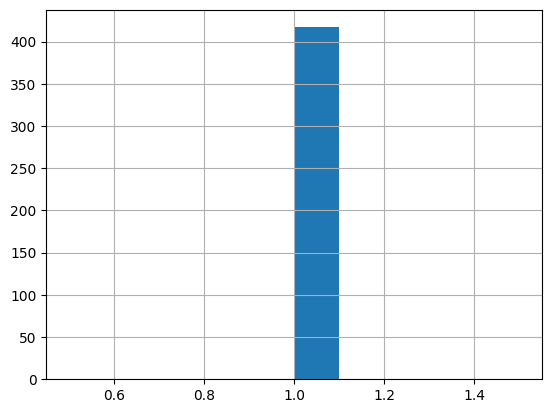

In [49]:
Hitter_Projections_df['FG ID'].value_counts().hist()

In [50]:
rest_of_roster_SP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'SP']
full_roster_SP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'SP']
rest_of_roster_RP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'RP']
full_roster_RP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'RP']
rest_of_roster_P_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'P']
full_roster_P_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'P']

In [51]:
rest_of_roster_SP_df['rest_of_roster_count'] = (Replacement_Level['SP']/Num_teams)-1.
full_roster_SP_df['full_roster_count'] = (Replacement_Level['SP']/Num_teams)
rest_of_roster_RP_df['rest_of_roster_count'] = (Replacement_Level['RP']/Num_teams)-1.
full_roster_RP_df['full_roster_count'] = (Replacement_Level['RP']/Num_teams)
rest_of_roster_P_df['rest_of_roster_count'] = (Replacement_Level['P']/Num_teams)-1.
full_roster_P_df['full_roster_count'] = (Replacement_Level['P']/Num_teams)

In [52]:
rest_of_roster_SP_df['rest_of_roster'] = rest_of_roster_SP_df['rest_of_roster_count']*rest_of_roster_SP_df['mean']
full_roster_SP_df['full_roster'] = full_roster_SP_df['full_roster_count']*full_roster_SP_df['mean']
rest_of_roster_RP_df['rest_of_roster'] = rest_of_roster_RP_df['rest_of_roster_count']*rest_of_roster_RP_df['mean']
full_roster_RP_df['full_roster'] = full_roster_RP_df['full_roster_count']*full_roster_RP_df['mean']
rest_of_roster_P_df['rest_of_roster'] = rest_of_roster_P_df['rest_of_roster_count']*rest_of_roster_P_df['mean']
full_roster_P_df['full_roster'] = full_roster_P_df['full_roster_count']*full_roster_P_df['mean']

In [53]:
rest_of_roster_SP_stats = rest_of_roster_SP_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_SP_stats = full_roster_SP_df.pivot_table('full_roster','Ottoneu Positions','Stat')
rest_of_roster_RP_stats = rest_of_roster_RP_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_RP_stats = full_roster_RP_df.pivot_table('full_roster','Ottoneu Positions','Stat')
rest_of_roster_P_stats = rest_of_roster_P_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_P_stats = full_roster_P_df.pivot_table('full_roster','Ottoneu Positions','Stat')

In [54]:
Pitcher_Projections_df['Ottoneu Positions'].value_counts().reset_index()

,Ottoneu Positions,count
0,RP,255
1,SP,152
2,SP/RP,77
3,Util/SP,1


<Axes: xlabel='IP', ylabel='Count'>

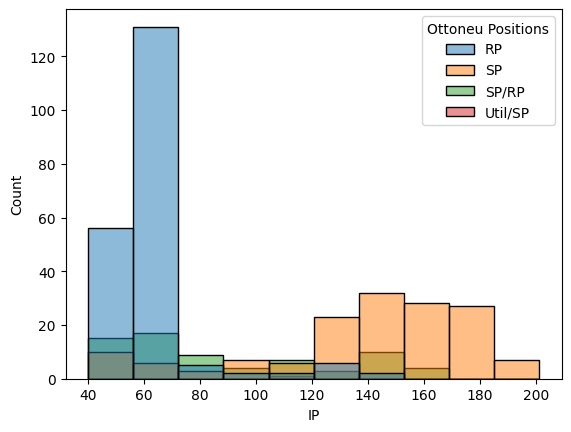

In [55]:
import seaborn as sns
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['WAR']>0.05],x='IP',hue='Ottoneu Positions')

In [56]:
League_Avg_HR9 = HR9(
            full_roster_P_stats['HR'].values[0],
            full_roster_P_stats['IP'].values[0])

League_Avg_SP_HR9 = HR9(
            full_roster_SP_stats['HR'].values[0],
            full_roster_SP_stats['IP'].values[0])

League_Avg_RP_HR9 = HR9(
            full_roster_RP_stats['HR'].values[0],
            full_roster_RP_stats['IP'].values[0])

League_Avg_ERA = ERA(
            full_roster_P_stats['ER'].values[0],
            full_roster_P_stats['IP'].values[0])

League_Avg_SP_ERA = ERA(
            full_roster_SP_stats['ER'].values[0],
            full_roster_SP_stats['IP'].values[0])

League_Avg_RP_ERA = ERA(
            full_roster_RP_stats['ER'].values[0],
            full_roster_RP_stats['IP'].values[0])

League_Avg_WHIP = WHIP(
            full_roster_P_stats['BB'].values[0],
            full_roster_P_stats['H'].values[0],
            full_roster_P_stats['IP'].values[0]
)

League_Avg_SP_WHIP = WHIP(
            full_roster_SP_stats['BB'].values[0],
            full_roster_SP_stats['H'].values[0],
            full_roster_SP_stats['IP'].values[0]
)

League_Avg_RP_WHIP = WHIP(
            full_roster_RP_stats['BB'].values[0],
            full_roster_RP_stats['H'].values[0],
            full_roster_RP_stats['IP'].values[0]
)

# P League Average

In [57]:
print('HR9', League_Avg_HR9)
print('SP HR9', League_Avg_SP_HR9)
print('RP HR9', League_Avg_RP_HR9)
print('ERA', League_Avg_ERA)
print('SP ERA', League_Avg_SP_ERA)
print('RP ERA', League_Avg_RP_ERA)
print('WHIP', League_Avg_WHIP)
print('SP WHIP', League_Avg_SP_WHIP)
print('RP WHIP', League_Avg_RP_WHIP)

HR9 1.1446610398534178
SP HR9 1.1662820691781495
RP HR9 1.076209537570472
ERA 3.94652217075989
SP ERA 3.9988862692954745
RP ERA 3.8200380539165257
WHIP 1.2538100714397304
SP WHIP 1.2569147953692366
RP WHIP 1.2549527363990594


In [58]:
Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<(Replacement_Level['P'])]

,FG ID,Team,W,L,QS,G,GS,SV,HLD,IP,...,ADP,POS,Ottoneu ID,Ottoneu Positions,Name,HR9,ERA,WHIP,Pos Place,SO_SGP_raw
2,10233,BOS,3.355612,3.199640,0.000000,61.23632,0.00000,30.385,2.353536,60.55644,...,46.840000,['RP'],5644,RP,Aroldis Chapman,0.849794,2.957060,1.161047,143.0,1.737819
3,10310,PHI,9.304912,5.024288,12.691840,20.43608,20.43608,0.000,0.000000,123.62880,...,148.449997,['SP'],15962,SP,Zack Wheeler,1.077212,3.156823,1.073152,29.0,3.040254
6,10603,ATL,11.719560,7.419640,15.904440,27.12540,27.12540,0.000,0.000000,163.14200,...,34.709999,['SP'],14393,SP,Chris Sale,1.002222,3.233025,1.101263,7.0,4.119805
7,10954,TEX,12.166440,7.737944,15.749920,28.16260,28.16260,0.000,0.000000,168.07600,...,47.349998,['SP'],14294,SP,Jacob DeGrom,1.203461,3.310372,1.069086,13.0,3.939428
9,11156,ARI,11.074600,10.016672,14.957760,30.01280,30.01280,0.000,0.000000,179.57960,...,229.899994,['SP'],17763,SP,Merrill Kelly,1.180407,4.176735,1.278588,72.0,3.350304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,35456,TOR,7.687032,5.779148,12.467712,32.08636,24.02976,0.000,0.685227,143.38960,...,151.289993,['SP'],45790,SP/RP,Trey Yesavage,1.097028,3.611798,1.234367,52.0,3.506347
795,9132,TEX,11.650400,8.553660,15.664440,27.84448,27.84448,0.000,0.075705,169.62240,...,146.449997,['SP'],9335,SP,Nathan Eovaldi,1.033185,3.613511,1.154089,19.0,3.404367
1728,sa3020707,MIA,7.029260,6.722076,9.363644,19.29048,19.29048,0.000,0.000000,113.13652,...,999.000000,['SP'],42741,SP,Robby Snelling,1.096627,4.153501,1.323766,108.0,2.127589
2219,sa3023268,MIA,4.215084,3.773152,5.235620,10.27906,10.27906,0.000,0.000000,62.18604,...,999.000000,['SP'],44487,SP,Thomas White,1.067980,3.886331,1.385957,178.0,1.457488


<Axes: >

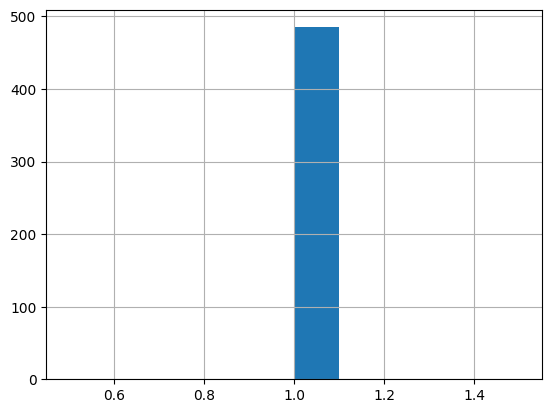

In [59]:
Pitcher_Projections_df['Pos Place'].value_counts().hist()

<Axes: xlabel='Pos Place', ylabel='Pos Place'>

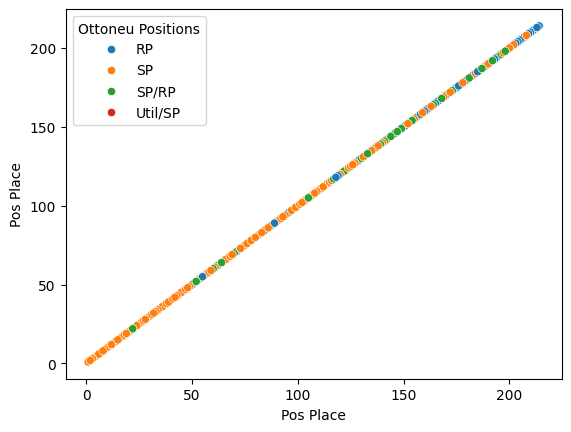

In [60]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='Pos Place',y='Pos Place',hue='Ottoneu Positions')

<Axes: xlabel='ERA', ylabel='Count'>

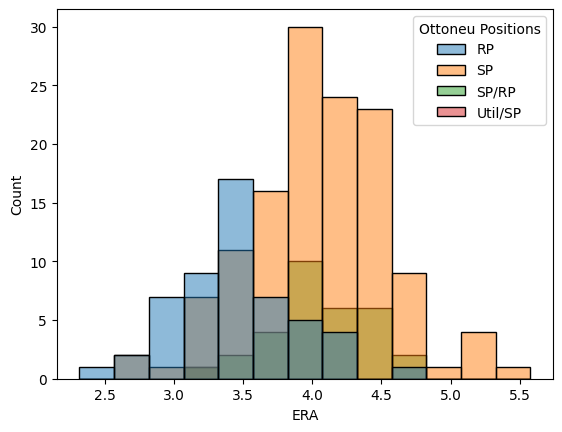

In [61]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='ERA',hue='Ottoneu Positions')

<Axes: xlabel='IP', ylabel='Count'>

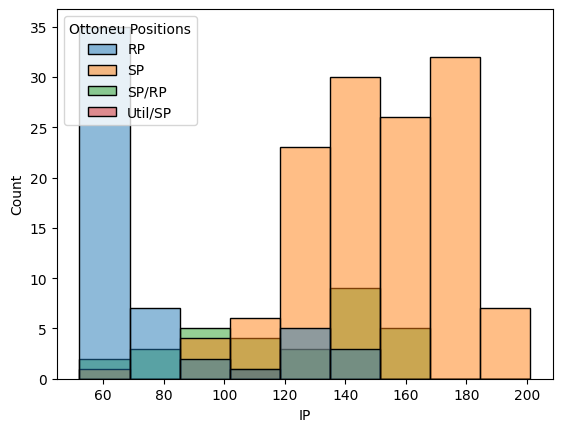

In [62]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='IP',hue='Ottoneu Positions')

In [63]:
Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))

0       False
1       False
2       False
3        True
6        True
        ...  
2172     True
2219     True
2252     True
2606    False
2823     True
Name: Ottoneu Positions, Length: 485, dtype: bool

In [64]:
Pitcher_Projections_df['HR9_SGP_raw'] = (
    HR9(
        (Pitcher_Projections_df['HR'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['HR'].values[0],
            rest_of_roster_RP_stats['HR'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['IP'].values[0],
            rest_of_roster_RP_stats['IP'].values[0]
            )
        )
        )
    - np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
        League_Avg_SP_HR9,
        League_Avg_RP_HR9
    )
) / SGP_Denom['HR9']

In [65]:
Pitcher_Projections_df['ERA_SGP_raw'] = (
    ERA(
        (Pitcher_Projections_df['ER'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['ER'].values[0],
            rest_of_roster_RP_stats['ER'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['IP'].values[0],
            rest_of_roster_RP_stats['IP'].values[0]
            )
        )
        )
    - np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
        League_Avg_SP_ERA,
        League_Avg_RP_ERA
    )
) / SGP_Denom['ERA']

In [66]:
Pitcher_Projections_df['WHIP_SGP_raw'] = (
    WHIP(
        (Pitcher_Projections_df['BB'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['BB'].values[0],
            rest_of_roster_RP_stats['BB'].values[0]
            )
        ),
        (Pitcher_Projections_df['H'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['H'].values[0],
            rest_of_roster_RP_stats['H'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['IP'].values[0],
            rest_of_roster_RP_stats['IP'].values[0]
            )
        )
        )
    - np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
        League_Avg_SP_WHIP,
        League_Avg_RP_WHIP
    )
) / SGP_Denom['WHIP']

In [67]:
Pitcher_Projections_df['TOTAL_SGP_raw'] = Pitcher_Projections_df[[f'{col}_SGP_raw' for col in Scoring_Categories_Pitching]].sum(axis=1)

In [68]:
Pitcher_Projections_df.sort_values('TOTAL_SGP_raw',ascending=False).head(10)

,FG ID,Team,W,L,QS,G,GS,SV,HLD,IP,...,Name,HR9,ERA,WHIP,Pos Place,SO_SGP_raw,HR9_SGP_raw,ERA_SGP_raw,WHIP_SGP_raw,TOTAL_SGP_raw
382,22267,DET,15.349680,7.016644,21.063400,31.15064,31.15064,0.00000,0.000000,198.89880,...,Tarik Skubal,0.882934,2.687728,0.987149,1.0,5.047605,1.137926,1.532817,1.616320,9.334669
768,33677,PIT,14.546840,8.081052,20.244960,31.28424,31.28424,0.00000,0.000000,193.44560,...,Paul Skenes,0.790954,2.767541,1.051617,2.0,4.880216,1.470204,1.404067,1.199767,8.954254
572,27463,BOS,14.298760,8.058244,18.816000,30.92356,30.92356,0.00000,0.000000,190.40240,...,Garrett Crochet,0.904065,3.008174,1.074135,3.0,4.891730,1.012598,1.113694,1.053056,8.071079
737,31757,SDP,3.076936,2.781668,0.021111,64.23908,0.02887,31.83908,2.673772,65.83292,...,Mason Miller,0.806302,2.315414,0.993832,89.0,2.113607,1.327164,2.153675,1.915578,7.510025
311,20778,PHI,13.950640,8.509576,19.210720,30.93348,30.93348,0.00000,0.000000,196.68680,...,Cristopher Sanchez,0.815298,3.207583,1.146105,4.0,4.096347,1.395496,0.915855,0.657303,7.065000
163,17995,SFG,13.585360,9.458360,18.867920,31.32116,31.32116,0.00000,0.075125,201.10720,...,Logan Webb,0.765265,3.392781,1.189805,5.0,4.071382,1.626477,0.715608,0.406085,6.819553
316,21029,PHI,4.204012,3.459152,0.000000,69.25068,0.00000,30.05712,3.070296,69.05388,...,Jhoan Duran,0.659828,2.709456,1.110158,96.0,1.716289,2.134209,1.657059,1.107250,6.614807
709,30279,SEA,14.292640,8.666328,18.715160,31.01756,31.01756,0.00000,0.000000,193.10920,...,Bryan Woo,1.150858,3.224773,1.046878,12.0,4.214168,0.060322,0.881320,1.225547,6.381358
626,27867,CLE,4.217688,3.237512,0.000000,69.89816,0.00000,29.98508,3.480984,69.97464,...,Cade Smith,0.762575,2.886981,1.072864,100.0,1.870485,1.626111,1.408241,1.408505,6.313341
6,10603,ATL,11.719560,7.419640,15.904440,27.12540,27.12540,0.00000,0.000000,163.14200,...,Chris Sale,1.002222,3.233025,1.101263,7.0,4.119805,0.550765,0.748435,0.779584,6.198589


<Axes: >

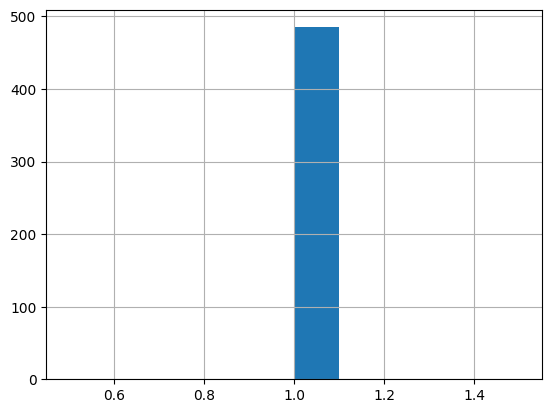

In [69]:
Pitcher_Projections_df['FG ID'].value_counts().hist()

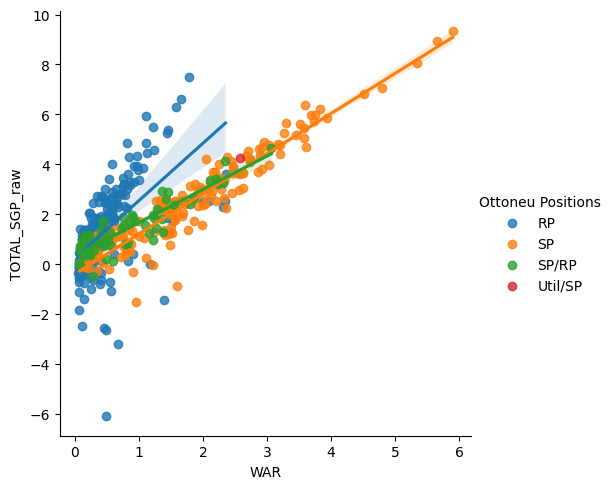

In [70]:
sns.lmplot(Pitcher_Projections_df[Pitcher_Projections_df['WAR']>0.05],x='WAR',y='TOTAL_SGP_raw',hue='Ottoneu Positions')

# Replacement Level SGP

In [71]:
Hitting_Replacement_pivot_df = Hitting_Replacement_Stats_df.pivot_table('mean','Ottoneu Positions','Stat').reset_index()

In [72]:
Hitting_Replacement_pivot_df

Stat,Ottoneu Positions,1B,2B,3B,AB,ADP,BB,G,H,HBP,HR,PA,R,RBI,SF,WAR
0,1B,86.236216,25.893128,1.290731,526.57392,233.006000,42.975880,137.871040,133.628880,6.408196,20.208816,581.48824,67.185072,71.281104,4.157530,1.469128
1,2B,78.184096,25.503712,1.621655,485.98040,348.915997,50.664192,130.124240,119.750800,8.061423,14.561344,550.42160,64.370024,60.321640,3.975922,1.609192
2,3B,74.526048,23.578152,1.508494,460.77960,290.091995,40.904536,122.267200,114.873448,7.084581,14.900736,513.95312,60.015544,58.293928,3.511247,1.773587
3,C,54.393240,15.773840,0.897672,355.98152,479.438000,36.384608,102.441272,83.123616,4.096947,11.818872,400.58312,44.563976,43.879256,2.870915,1.711543
4,OF,63.926152,19.605192,3.348512,410.88360,488.942004,42.009872,110.628000,97.788904,5.796318,11.029041,464.09664,56.994336,47.020368,3.317722,0.982611
5,SS,52.489288,16.078944,2.063161,333.36664,549.283997,33.024080,88.749120,79.725640,3.900200,9.214279,374.29224,44.296264,38.857616,2.778590,1.288699
6,Util,62.321040,19.859248,0.859891,415.14384,369.806000,41.902128,111.244352,98.999504,5.638338,16.079319,466.87376,53.564856,55.538896,3.300113,0.929414


In [73]:
Hitting_Replacement_SGP_df = pd.DataFrame()
for pos in Hitting_Pos:
    this_pos_repl_df = Hitting_Replacement_pivot_df[Hitting_Replacement_pivot_df['Ottoneu Positions'] == pos]
    This_pos_dict = {
            'Ottoneu Positions':pos,
        }
    quick_running_sum = 0.
    for stat in Count_Scoring_Categories_Batting:
        Repl_mean = this_pos_repl_df[f'{stat}'].values[0]

        This_pos_dict[f'{stat}_SGP_raw'] = Repl_mean/SGP_Denom[stat]
        quick_running_sum += This_pos_dict[f'{stat}_SGP_raw']

    This_pos_dict['OBP'] = OBP(
        (this_pos_repl_df['H'].values[0]),
        (this_pos_repl_df['BB'].values[0]),
        (this_pos_repl_df['HBP'].values[0]),
        (this_pos_repl_df['SF'].values[0]),
        (this_pos_repl_df['AB'].values[0])
    )

    This_pos_dict['OBP_SGP_raw'] = (OBP(
        (this_pos_repl_df['H'].values[0]+rest_of_roster_stats['H'].values[0]),
        (this_pos_repl_df['BB'].values[0]+rest_of_roster_stats['BB'].values[0]),
        (this_pos_repl_df['HBP'].values[0]+rest_of_roster_stats['HBP'].values[0]),
        (this_pos_repl_df['SF'].values[0]+rest_of_roster_stats['SF'].values[0]),
        (this_pos_repl_df['AB'].values[0]+rest_of_roster_stats['AB'].values[0])) \
    - full_roster_OBP) / SGP_Denom['OBP']

    quick_running_sum += This_pos_dict['OBP_SGP_raw']
    
    repl_level_TB = TB(
    this_pos_repl_df['1B'].values[0],
    this_pos_repl_df['2B'].values[0],
    this_pos_repl_df['3B'].values[0],
    this_pos_repl_df['HR'].values[0])

    This_pos_dict['SLG'] = SLG(
        (repl_level_TB),
        (this_pos_repl_df['AB'].values[0])
    )

    This_pos_dict['SLG_SGP_raw'] = (
    SLG(
        (repl_level_TB+rest_of_roster_TB),
        (this_pos_repl_df['AB'].values[0]+rest_of_roster_stats['AB'].values[0])) \
    -  full_roster_SLG) / SGP_Denom['SLG']

    quick_running_sum += This_pos_dict['SLG_SGP_raw']

    This_pos_dict['TOTAL_SGP_raw'] = quick_running_sum

    Hitting_Replacement_SGP_df = pd.concat([
        Hitting_Replacement_SGP_df,
        pd.DataFrame([This_pos_dict])
    ])

In [74]:
Hitting_Replacement_SGP_df

,Ottoneu Positions,R_SGP_raw,HR_SGP_raw,OBP,OBP_SGP_raw,SLG,SLG_SGP_raw,TOTAL_SGP_raw
0,C,1.762640,1.026978,0.309528,-0.255931,0.381788,-0.319804,2.213883
0,1B,2.657373,1.756005,0.315477,-0.235854,0.422979,-0.032305,4.145219
0,2B,2.546029,1.265279,0.325282,-0.021051,0.395699,-0.295283,3.494974
0,SS,1.752051,0.800657,0.312676,-0.194713,0.383043,-0.291704,2.066291
0,3B,2.373796,1.294770,0.317917,-0.162351,0.403253,-0.210868,3.295346
0,OF,2.254298,0.958347,0.315136,-0.195928,0.382829,-0.358333,2.658384
0,Util,2.118652,1.397181,0.314474,-0.209250,0.406935,-0.160087,3.146496


In [75]:
Hitting_Replacement_SGP_df = Hitting_Replacement_SGP_df.set_index('Ottoneu Positions')

In [76]:
pd.DataFrame(Hitter_Projections_df['Ottoneu Positions'].apply(lambda x : (min(Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))]['R_SGP_raw']),Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))]['TOTAL_SGP_raw'].idxmin())).to_list(),index=Hitter_Projections_df.index)

,0,1
1,2.254298,OF
3,2.254298,OF
4,2.254298,OF
5,2.373796,3B
6,2.657373,1B
...,...,...
1638,2.254298,OF
1695,2.254298,OF
1792,2.254298,OF
1847,2.373796,3B


In [77]:
for stat in Scoring_Categories_Batting:
    Hitter_Projections_df[[f'{stat}_SGP_repl','Repl_Pos']] = pd.DataFrame(Hitter_Projections_df['Ottoneu Positions'].apply(lambda x : (min(Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))][f'{stat}_SGP_raw']),Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))]['TOTAL_SGP_raw'].idxmin())).to_list(),index=Hitter_Projections_df.index)
    Hitter_Projections_df[f'{stat}_SGP_norm'] = Hitter_Projections_df[f'{stat}_SGP_raw'] - Hitter_Projections_df[f'{stat}_SGP_repl']

In [78]:
Hitter_Projections_df.head()

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,TOTAL_SGP_raw,R_SGP_repl,Repl_Pos,R_SGP_norm,HR_SGP_repl,HR_SGP_norm,OBP_SGP_repl,OBP_SGP_norm,SLG_SGP_repl,SLG_SGP_norm
1,10155,LAA,129.1444,556.3820,472.4704,113.9432,65.56196,19.01020,1.917732,27.45316,...,6.122119,2.254298,OF,0.659201,0.958347,1.427141,-0.195928,0.661333,-0.358333,0.716060
3,10815,ATL,144.9268,627.0208,543.6880,134.1240,90.24152,26.13876,0.992002,16.75172,...,4.331953,2.254298,OF,0.708359,0.958347,0.497261,-0.195928,0.490370,-0.358333,-0.022420
4,11477,MIL,142.5496,612.5212,536.5336,137.0560,92.19288,23.32544,1.235164,19.70256,...,4.877910,2.254298,OF,0.721801,0.958347,0.753668,-0.195928,0.529752,-0.358333,0.214305
5,11493,SDP,148.4948,643.5320,583.9552,153.9600,97.82496,27.65708,0.362564,27.51544,...,5.692741,2.373796,3B,0.679889,1.294770,1.096130,-0.162351,0.103678,-0.210868,0.517698
6,11579,PHI,149.4068,644.4472,556.8308,150.4592,87.70540,33.69104,0.377485,29.28532,...,7.537020,2.657373,1B,0.761401,1.756005,0.788685,-0.235854,1.091909,-0.032305,0.749807


In [79]:
Hitter_Projections_df.groupby('Repl_Pos')['Ottoneu Positions'].value_counts()

Repl_Pos  Ottoneu Positions
1B        1B                    28
2B        2B                    16
          1B/2B                  3
3B        3B                    25
          2B/3B                 13
          1B/3B                  5
          1B/2B/3B               2
C         C                     58
          C/1B                   6
OF        OF                   145
          1B/OF                 10
          2B/OF                  9
          2B/3B/OF               6
          3B/OF                  3
          1B/2B/OF               3
          1B/3B/OF               1
          1B/OF/RP               1
SS        SS                    28
          2B/SS                 17
          2B/SS/3B               8
          2B/SS/3B/OF            6
          1B/2B/SS/3B            6
          2B/SS/OF               3
          SS/3B/OF               2
          SS/3B                  2
          2B/SS/3B/OF/RP         1
          1B/SS/3B/OF            1
          SS/OF            

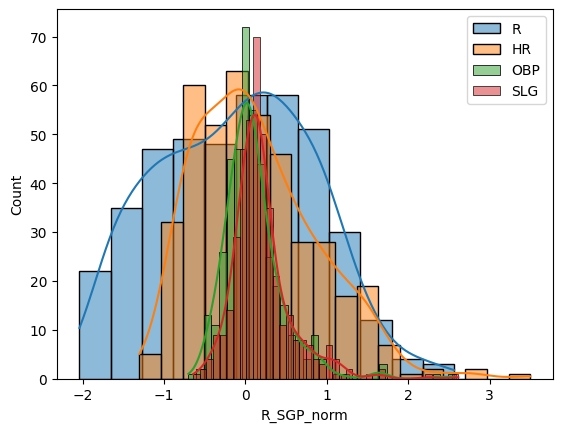

In [80]:
for stat in Scoring_Categories_Batting:
    sns.histplot(Hitter_Projections_df,x=f'{stat}_SGP_norm',label=stat,kde=True)
    #Hitter_Projections_df[f'{stat}_SGP_norm'].hist(label=stat)
plt.legend()

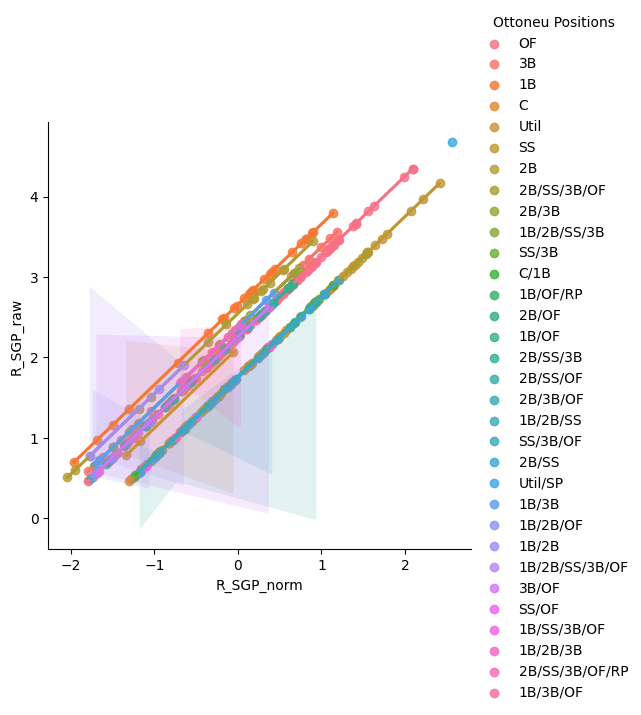

In [81]:
sns.lmplot(Hitter_Projections_df[Hitter_Projections_df['WAR']>0.05],x='R_SGP_norm',y='R_SGP_raw',hue='Ottoneu Positions')

In [82]:
Pitching_Replacement_pivot_df = Pitching_Replacement_Stats_df.pivot_table('mean','Ottoneu Positions','Stat').reset_index()

In [83]:
Pitching_Replacement_pivot_df

Stat,Ottoneu Positions,ADP,BB,ER,G,GS,H,HBP,HLD,HR,IP,L,QS,R,SO,SV,TBF,W,WAR
0,P,516.502003,23.054592,23.398992,51.505574,1.276645,47.312136,2.788537,11.189290,7.229375,57.864208,2.919914,0.752152,25.444120,66.900832,6.361849,243.30528,2.994027,0.602587
1,RP,306.586009,24.893320,28.271632,51.043368,3.432217,58.986912,3.171967,7.317869,8.370346,67.602784,2.970956,1.647239,30.829160,71.164976,8.484022,284.77272,3.244908,0.779987
2,SP,585.916003,34.797648,54.271368,31.622184,17.090272,108.171056,4.972670,0.731302,16.124576,107.851744,5.259526,7.519346,59.011496,86.985752,0.004815,463.38848,4.682026,0.807103


In [84]:
Pitching_Replacement_SGP_df = pd.DataFrame()
for pos in Pitching_Pos:
    this_pos_repl_df = Pitching_Replacement_pivot_df[Pitching_Replacement_pivot_df['Ottoneu Positions'] == pos]
    This_pos_dict = {
            'Ottoneu Positions':pos,
        }
    quick_running_sum = 0.
    for stat in Count_Scoring_Categories_Pitching:
        Repl_mean = this_pos_repl_df[f'{stat}'].values[0]

        This_pos_dict[f'{stat}_SGP_raw'] = Repl_mean/SGP_Denom[stat]
        quick_running_sum += This_pos_dict[f'{stat}_SGP_raw']

    This_pos_dict['HR9'] = HR9(
        this_pos_repl_df['HR'].values[0],
        this_pos_repl_df['IP'].values[0]
    )

    This_pos_dict['HR9_SGP_raw'] = (
    HR9(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['HR'].values[0]+rest_of_roster_SP_stats['HR'].values[0]),
            (this_pos_repl_df['HR'].values[0]+rest_of_roster_RP_stats['HR'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_SP_stats['IP'].values[0]),
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_RP_stats['IP'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        HR9(
            full_roster_SP_stats['HR'].values[0],
            full_roster_SP_stats['IP'].values[0]),
        HR9(
            full_roster_RP_stats['HR'].values[0],
            full_roster_RP_stats['IP'].values[0])     
    ) ) / SGP_Denom['HR9']

    quick_running_sum += This_pos_dict['HR9_SGP_raw']

    This_pos_dict['ERA'] = ERA(
        this_pos_repl_df['ER'].values[0],
        this_pos_repl_df['IP'].values[0]
    )

    This_pos_dict['ERA_SGP_raw'] = (
    ERA(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['ER'].values[0]+rest_of_roster_SP_stats['ER'].values[0]),
            (this_pos_repl_df['ER'].values[0]+rest_of_roster_RP_stats['ER'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_SP_stats['IP'].values[0]),
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_RP_stats['IP'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        ERA(
            full_roster_SP_stats['ER'].values[0],
            full_roster_SP_stats['IP'].values[0]),
        ERA(
            full_roster_RP_stats['ER'].values[0],
            full_roster_RP_stats['IP'].values[0])     
    ) ) / SGP_Denom['ERA']

    quick_running_sum += This_pos_dict['ERA_SGP_raw']


    This_pos_dict['WHIP'] = WHIP(
        this_pos_repl_df['BB'].values[0],
        this_pos_repl_df['H'].values[0],
        this_pos_repl_df['IP'].values[0]
    )

    This_pos_dict['WHIP_SGP_raw'] = (
    WHIP(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['BB'].values[0]+rest_of_roster_SP_stats['BB'].values[0]),
            (this_pos_repl_df['BB'].values[0]+rest_of_roster_RP_stats['BB'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['H'].values[0]+rest_of_roster_SP_stats['H'].values[0]),
            (this_pos_repl_df['H'].values[0]+rest_of_roster_RP_stats['H'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_SP_stats['IP'].values[0]),
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_RP_stats['IP'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        WHIP(
            full_roster_SP_stats['BB'].values[0],
            full_roster_SP_stats['H'].values[0],
            full_roster_SP_stats['IP'].values[0]),
        WHIP(
            full_roster_RP_stats['BB'].values[0],
            full_roster_RP_stats['H'].values[0],
            full_roster_RP_stats['IP'].values[0])     
    ) ) / SGP_Denom['WHIP']

    quick_running_sum += This_pos_dict['WHIP_SGP_raw']

    This_pos_dict['TOTAL_SGP_raw'] = quick_running_sum

    Pitching_Replacement_SGP_df = pd.concat([
        Pitching_Replacement_SGP_df,
        pd.DataFrame([This_pos_dict])
    ])

In [85]:
Pitching_Replacement_SGP_df

,Ottoneu Positions,SO_SGP_raw,HR9,HR9_SGP_raw,ERA,ERA_SGP_raw,WHIP,WHIP_SGP_raw,TOTAL_SGP_raw
0,SP,1.830403,1.345562,-0.410019,4.528831,-0.352813,1.325604,-0.234374,0.833197
0,RP,1.497493,1.114349,-0.191920,3.763820,0.082350,1.240781,0.106395,1.494318
0,P,1.407765,1.124432,-0.211693,3.639399,0.230839,1.216067,0.254682,1.681593


In [86]:
Pitching_Replacement_SGP_df = Pitching_Replacement_SGP_df.set_index('Ottoneu Positions')

In [87]:
Pitcher_Projections_df['Ottoneu Positions'].value_counts()

Ottoneu Positions
RP         255
SP         152
SP/RP       77
Util/SP      1
Name: count, dtype: int64

In [88]:
for stat in Scoring_Categories_Pitching:
    Pitcher_Projections_df[[f'{stat}_SGP_repl','Repl_Pos']] = pd.DataFrame(Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : (min(Pitching_Replacement_SGP_df[Pitching_Replacement_SGP_df.index.isin(x.split('/'))][f'{stat}_SGP_raw']),Pitching_Replacement_SGP_df[Pitching_Replacement_SGP_df.index.isin(x.split('/'))]['TOTAL_SGP_raw'].idxmin())).to_list(),index=Pitcher_Projections_df.index)
    Pitcher_Projections_df[f'{stat}_SGP_norm'] = Pitcher_Projections_df[f'{stat}_SGP_raw'] - Pitcher_Projections_df[f'{stat}_SGP_repl']

In [89]:
Pitcher_Projections_df['TOTAL_SGP'] = Pitcher_Projections_df[[f'{col}_SGP_norm' for col in Scoring_Categories_Pitching]].sum(axis=1)
Hitter_Projections_df['TOTAL_SGP'] = Hitter_Projections_df[[f'{col}_SGP_norm' for col in Scoring_Categories_Batting]].sum(axis=1)

In [90]:
Hitter_Projections_df.sort_values(['TOTAL_SGP'])

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,R_SGP_repl,Repl_Pos,R_SGP_norm,HR_SGP_repl,HR_SGP_norm,OBP_SGP_repl,OBP_SGP_norm,SLG_SGP_repl,SLG_SGP_norm,TOTAL_SGP
115,18373,BAL,36.72984,155.1200,142.4324,36.49116,23.89752,7.280912,0.097633,5.215076,...,2.657373,1B,-1.963738,1.756005,-1.302851,-0.235854,0.114176,-0.032305,0.010043,-3.142370
494,29547,SEA,28.87252,117.8756,105.7868,23.08720,14.88348,5.104356,0.153392,2.945992,...,2.546029,2B,-2.040530,1.265279,-1.009293,-0.021051,-0.165593,-0.295283,0.133988,-3.081428
373,25714,COL,49.04684,203.7536,183.7976,45.76840,29.29548,9.366164,0.255932,6.250804,...,2.657373,1B,-1.749613,1.756005,-1.212854,-0.235854,0.135193,-0.032305,-0.060931,-2.888204
404,26208,SFG,43.27220,179.6624,163.8384,36.82464,23.35400,7.780040,0.962527,4.728072,...,2.546029,2B,-1.768165,1.265279,-0.854443,-0.021051,-0.284580,-0.295283,0.106923,-2.800265
514,29766,ATH,30.87480,128.7684,115.9164,25.49616,15.74616,5.670752,0.079981,4.599264,...,2.546029,2B,-1.952582,1.265279,-0.865635,-0.021051,-0.158590,-0.295283,0.218997,-2.757811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,16478,PHI,156.75480,678.8604,568.5348,134.05040,68.59052,21.278320,0.991106,42.590280,...,2.254298,OF,1.561714,0.958347,2.742452,-0.195928,0.860906,-0.358333,1.196651,6.361723
374,25764,KCR,156.00360,674.3132,610.9472,182.21360,107.51320,37.822520,6.427264,30.450600,...,1.752051,SS,2.413911,0.800657,1.845288,-0.194713,0.942012,-0.291704,1.554758,6.755969
199,20123,NYM,157.97520,684.2876,552.7056,154.57600,88.31900,26.260240,1.757820,38.839080,...,2.254298,OF,1.992067,0.958347,2.416498,-0.195928,2.354682,-0.358333,1.669681,8.432928
168,19755,LAD,154.56480,675.7600,576.2060,164.76240,82.63564,28.285600,5.875840,48.565160,...,2.118652,Util,2.564426,1.397181,2.822793,-0.209250,1.672190,-0.160087,2.253519,9.312928


<Axes: xlabel='ADP', ylabel='TOTAL_SGP'>

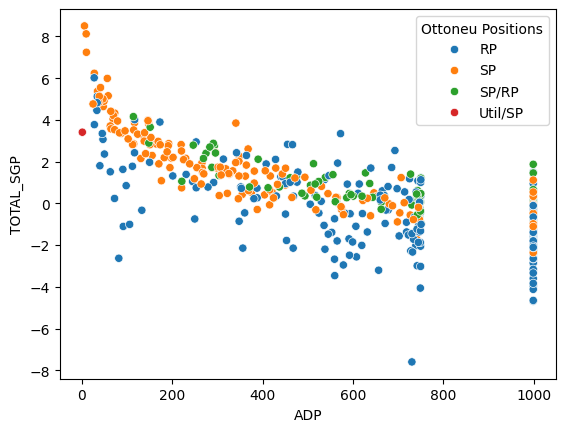

In [91]:
sns.scatterplot(Pitcher_Projections_df,y='TOTAL_SGP',x='ADP',hue='Ottoneu Positions')

In [92]:
Pitcher_Projections_df['TOTAL_SGP_Rank'] = Pitcher_Projections_df['TOTAL_SGP'].rank(ascending=False)
Hitter_Projections_df['TOTAL_SGP_Rank'] = Hitter_Projections_df['TOTAL_SGP'].rank(ascending=False)

<Axes: xlabel='TOTAL_SGP_Rank', ylabel='TOTAL_SGP'>

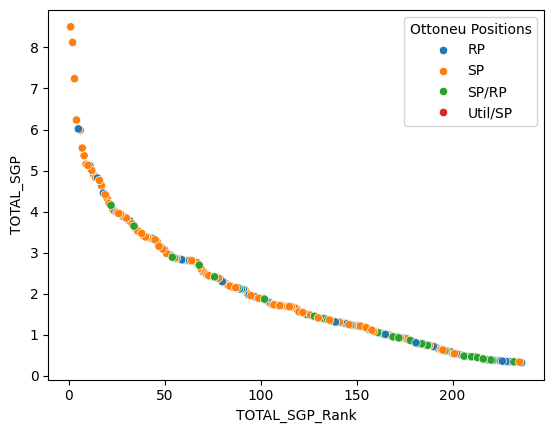

In [93]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']*1.1],x='TOTAL_SGP_Rank',y='TOTAL_SGP',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

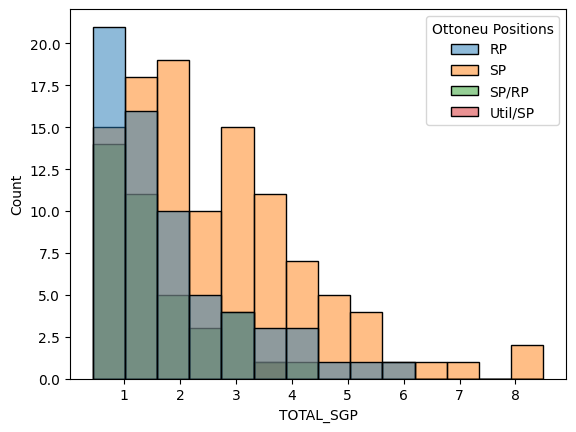

In [94]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']],x='TOTAL_SGP',hue='Ottoneu Positions')

<Axes: xlabel='ADP', ylabel='TOTAL_SGP'>

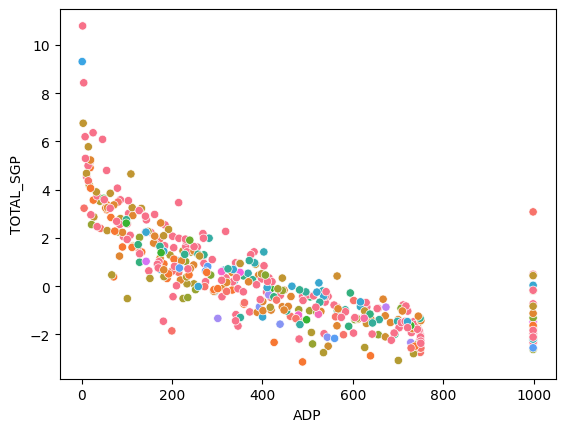

In [95]:
sns.scatterplot(Hitter_Projections_df,y='TOTAL_SGP',x='ADP',hue='Ottoneu Positions',legend=False)

<Axes: xlabel='TOTAL_SGP_Rank', ylabel='TOTAL_SGP'>

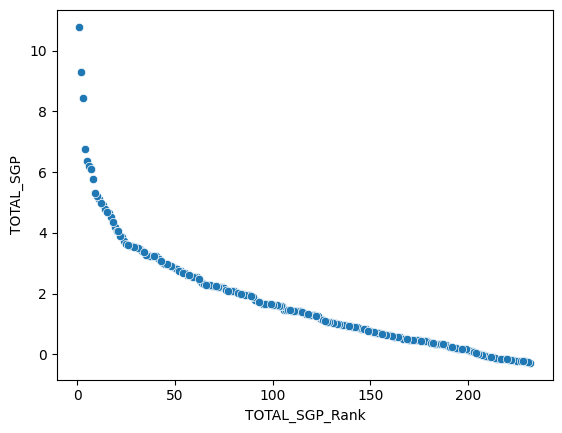

In [96]:
sns.scatterplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']],x='TOTAL_SGP_Rank',y='TOTAL_SGP')

In [97]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP'] > 0.]['TOTAL_SGP'].count()/Num_teams

np.float64(17.083333333333332)

In [98]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']]['TOTAL_SGP'].count()/Num_teams

np.float64(19.333333333333332)

In [99]:
Pitcher_Projections_df[(Pitcher_Projections_df['TOTAL_SGP'] > 0.)].groupby('Ottoneu Positions')['TOTAL_SGP'].count()/Num_teams

Ottoneu Positions
RP          7.333333
SP         10.250000
SP/RP       5.083333
Util/SP     0.083333
Name: TOTAL_SGP, dtype: float64

In [100]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']].groupby('Ottoneu Positions')['TOTAL_SGP'].count()/Num_teams

Ottoneu Positions
RP         5.416667
SP         9.083333
SP/RP      3.250000
Util/SP    0.083333
Name: TOTAL_SGP, dtype: float64

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

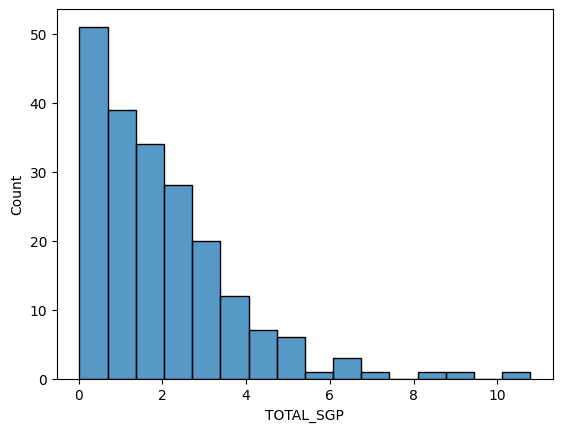

In [101]:
sns.histplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP'] > 0.],x='TOTAL_SGP')

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

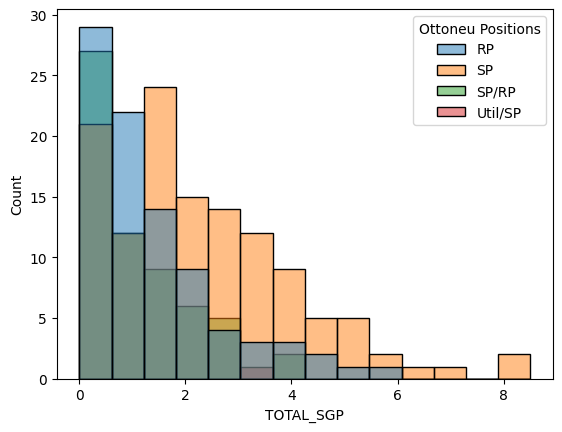

In [102]:
sns.histplot(Pitcher_Projections_df[(Pitcher_Projections_df['TOTAL_SGP'] > 0.)],x='TOTAL_SGP',hue='Ottoneu Positions')

In [103]:
# Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']]['TOTAL_SGP'].sum()

In [104]:
Hitter_budget/12

212.0

In [105]:
Val_per_SGP_Hitter = Hitter_budget/(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] <= Replacement_Level['Util']]['TOTAL_SGP'].sum())

In [106]:
Val_per_SGP_Hitter

np.float64(6.349899134101533)

In [107]:
Hitter_Projections_df['TOTAL_SGP_Val'] = Hitter_Projections_df['TOTAL_SGP']*Val_per_SGP_Hitter

In [108]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] <= Replacement_Level['Util']]['TOTAL_SGP'].count()

np.int64(233)

In [109]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP'].count()

np.int64(205)

In [110]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] <= Replacement_Level['Util']]['TOTAL_SGP_Val'].sum()/Num_teams

np.float64(212.0)

In [111]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP_Val'].sum()/Num_teams

np.float64(214.43237905581944)

In [112]:
Hitter_Projections_df[(Hitter_Projections_df['TOTAL_SGP_Rank'] <= Replacement_Level['Util']+Replacement_window['Util']/2) & (Hitter_Projections_df['TOTAL_SGP_Rank'] >= Replacement_Level['Util']-Replacement_window['Util']/2)]['TOTAL_SGP_Val'].mean()

np.float64(-2.0769996787121907)

In [113]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 0.].groupby(['Repl_Pos'])[['Ottoneu Positions']].count()

,Ottoneu Positions
Repl_Pos,
1B,17
2B,9
3B,17
C,28
OF,89
SS,43
Util,2


In [114]:
Replacement_Level

{'C': 24,
 '1B': 25,
 '2B': 27,
 'SS': 44,
 '3B': 19,
 'OF': 89,
 'Util': 233,
 'SP': 150,
 'RP': 65,
 'P': 215}

In [115]:
for stat in Scoring_Categories_Batting:
    Val_per_stat_SGP_Hitter = Hitter_budget/(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']][f'{stat}_SGP_norm'].sum())
    Hitter_Projections_df[f'{stat}_SGP_Val'] = Hitter_Projections_df[f'{stat}_SGP_norm']*Val_per_stat_SGP_Hitter
    print(stat, Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 0.][f'{stat}_SGP_Val'].sum()/Num_teams)

R 219.89499024609896
HR 211.38459301404305
OBP 213.60736972021596
SLG 210.251678269111


<Axes: xlabel='TOTAL_SGP_Val', ylabel='Count'>

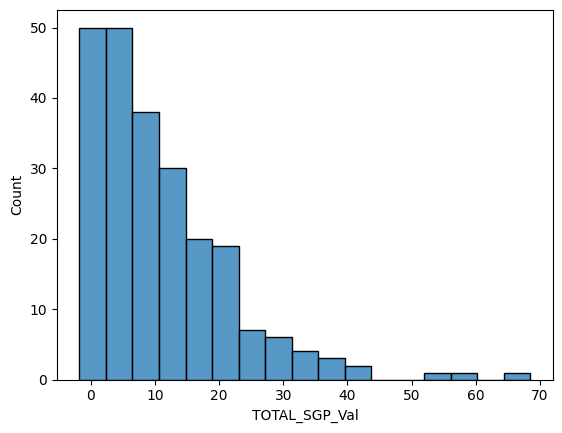

In [116]:
sns.histplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']],x='TOTAL_SGP_Val')

In [117]:
print(f'Pct bias Hitting: {(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP_Val'].sum() - Hitter_budget)/Hitter_budget*100:.2f}%')

Pct bias Hitting: 1.15%


<Axes: xlabel='TOTAL_SGP_Val', ylabel='TOTAL_SGP'>

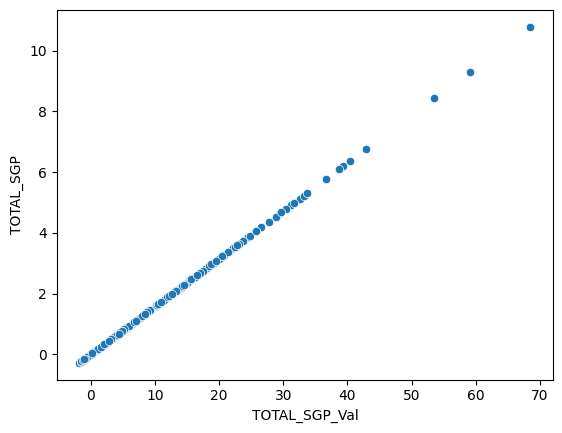

In [118]:
sns.scatterplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']],x='TOTAL_SGP_Val',y='TOTAL_SGP')

In [119]:
# Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']]['TOTAL_SGP'].sum()

In [120]:
Val_per_SGP_Pitcher = Pitcher_budget/(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']]['TOTAL_SGP'].sum())

In [121]:
Pitcher_Projections_df['TOTAL_SGP_Val'] = Pitcher_Projections_df['TOTAL_SGP']*Val_per_SGP_Pitcher

In [122]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']]['TOTAL_SGP'].count()

np.int64(214)

In [123]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP'].count()

np.int64(273)

In [124]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP_Val'].sum()/Num_teams

np.float64(191.08390765888734)

In [125]:
for stat in Scoring_Categories_Pitching:
    Val_per_stat_SGP_Pitcher = Pitcher_budget/(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']][f'{stat}_SGP_norm'].sum())
    Pitcher_Projections_df[f'{stat}_SGP_Val'] = Pitcher_Projections_df[f'{stat}_SGP_norm']*Val_per_stat_SGP_Pitcher
    print(stat, Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.][f'{stat}_SGP_Val'].sum()/Num_teams)

SO 177.10561481303844
HR9 212.09750640232042
ERA 201.2247506769678
WHIP 193.8862961494932


In [126]:
print(f'Pct bias Pitching: {(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP_Val'].sum() - Pitcher_budget)/Pitcher_budget*100:.2f}%')

Pct bias Pitching: 1.64%


<Axes: xlabel='TOTAL_SGP_Val', ylabel='TOTAL_SGP'>

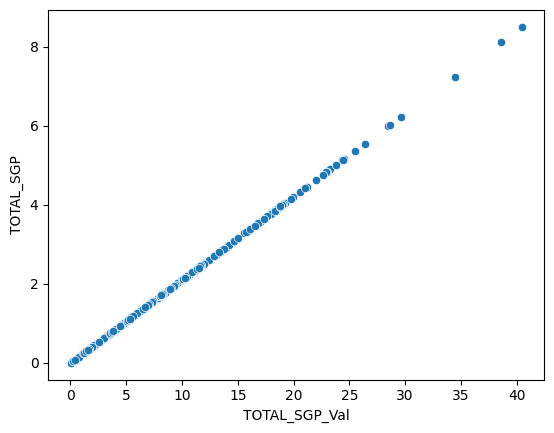

In [127]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.],x='TOTAL_SGP_Val',y='TOTAL_SGP')

In [128]:
Pitcher_Projections_df[Player_id_cols+['IP','SO','HR9','ERA','WHIP','SO_SGP_Val','HR9_SGP_Val','ERA_SGP_Val','WHIP_SGP_Val','TOTAL_SGP','TOTAL_SGP_Val']].sort_values('TOTAL_SGP_Val',ascending=False)

,FG ID,Ottoneu ID,Name,Ottoneu Positions,Team,IP,SO,HR9,ERA,WHIP,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val,TOTAL_SGP,TOTAL_SGP_Val
382,22267,35204,Tarik Skubal,SP,DET,198.89880,239.87600,0.882934,2.687728,0.987149,39.944185,27.463353,43.550677,68.526120,8.501472,40.442497
768,33677,43894,Paul Skenes,SP,PIT,193.44560,231.92120,0.790954,2.767541,1.051617,37.865910,33.358571,40.577052,53.102294,8.121057,38.632820
572,27463,38312,Garrett Crochet,SP,BOS,190.40240,232.46840,0.904065,3.008174,1.074135,38.008872,25.239815,33.870565,47.669997,7.237882,34.431451
311,20778,20975,Cristopher Sanchez,SP,PHI,196.68680,194.66960,0.815298,3.207583,1.146105,28.133538,32.033113,29.301254,33.016337,6.231803,29.645418
737,31757,40862,Mason Miller,RP,SDP,65.83292,100.44440,0.806302,2.315414,0.993832,7.649557,26.951306,47.839505,66.989088,6.015707,28.617422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,17556,23830,Jimmy Herget,RP,COL,79.68184,73.30852,1.395411,4.645474,1.355101,0.560023,-29.416325,-34.065012,-36.002566,-4.060169,-19.314698
751,31967,42728,Drew Thorpe,RP,CHW,69.27496,52.69152,1.377500,4.723535,1.363868,-4.826385,-24.069661,-33.123572,-34.864324,-4.121141,-19.604751
722,31552,42643,Zach Agnos,RP,COL,48.61224,40.41948,1.437977,5.127168,1.472559,-8.032584,-20.706382,-34.915587,-49.097546,-4.651797,-22.129141
352,21649,33485,Luis Medina,RP,ATH,109.99320,95.63456,1.194518,4.768603,1.451077,6.392936,-12.476512,-50.155108,-85.914164,-4.680204,-22.264279


<Axes: xlabel='TOTAL_SGP_Val', ylabel='SO_SGP_Val'>

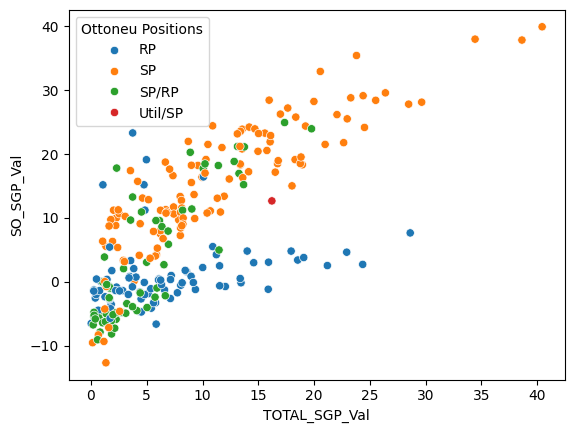

In [129]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.],x='TOTAL_SGP_Val',y='SO_SGP_Val',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='HR9_SGP_Val'>

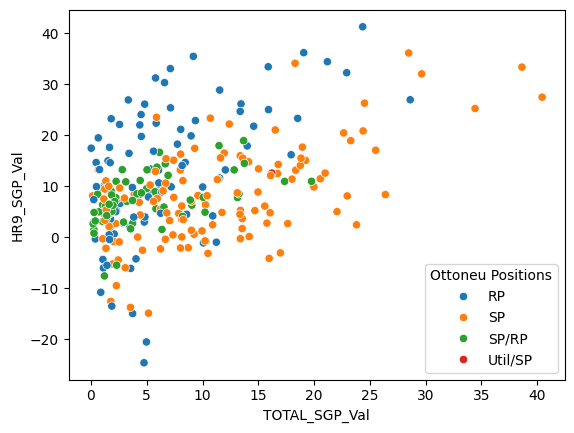

In [130]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.],x='TOTAL_SGP_Val',y='HR9_SGP_Val',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='ERA_SGP_Val'>

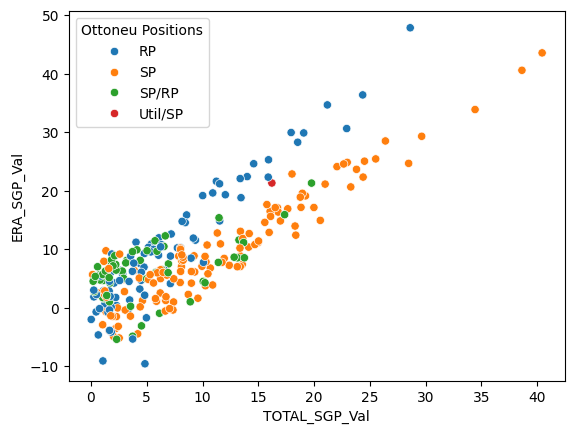

In [131]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.],x='TOTAL_SGP_Val',y='ERA_SGP_Val',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='WHIP_SGP_Val'>

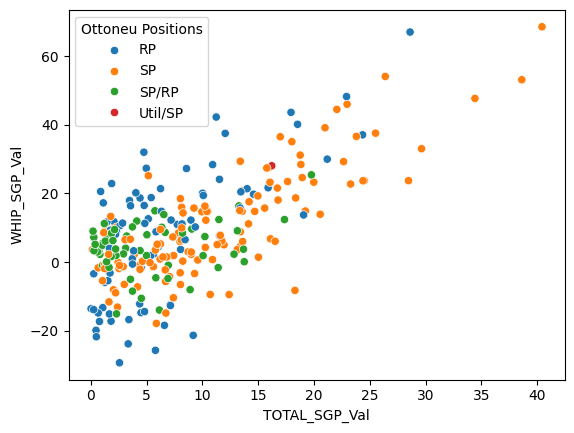

In [132]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.],x='TOTAL_SGP_Val',y='WHIP_SGP_Val',hue='Ottoneu Positions')

In [133]:
Hitter_Projections_df[Player_id_cols+['G','R','HR','OBP','SLG','R_SGP_Val','HR_SGP_Val','OBP_SGP_Val','SLG_SGP_Val','TOTAL_SGP','TOTAL_SGP_Val']].sort_values('TOTAL_SGP_Val',ascending=False)

,FG ID,Ottoneu ID,Name,Ottoneu Positions,Team,G,R,HR,OBP,SLG,R_SGP_Val,HR_SGP_Val,OBP_SGP_Val,SLG_SGP_Val,TOTAL_SGP,TOTAL_SGP_Val
58,15640,18312,Aaron Judge,OF,NYY,153.02520,109.91000,51.318920,0.422946,0.636914,40.347563,60.801380,137.491776,89.001827,10.791843,68.527112
168,19755,33600,Shohei Ohtani,Util/SP,LAD,154.56480,118.40000,48.565160,0.384457,0.609322,49.436025,49.024321,89.048654,76.666987,9.312928,59.136156
199,20123,23717,Juan Soto,OF,NYM,157.97520,107.35880,38.839080,0.411102,0.545443,38.402304,41.968077,125.393212,56.804207,8.432928,53.548243
374,25764,36668,Bobby Witt Jr.,SS,KCR,156.00360,105.32600,30.450600,0.356083,0.530721,46.534447,32.047691,50.164699,52.894414,6.755969,42.899719
69,16478,18347,Kyle Schwarber,OF,PHI,156.75480,96.47840,42.590280,0.352638,0.500377,30.106128,47.629006,45.845579,40.711280,6.361723,40.396300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,29766,40456,Zack Gelof,2B,ATH,30.87480,15.00384,4.599264,0.290828,0.394462,-37.641127,-15.033756,-8.445372,7.450484,-2.757811,-17.511821
404,26208,37662,Tyler Fitzgerald,2B,SFG,43.27220,19.66636,4.728072,0.282410,0.370572,-34.086011,-14.839372,-15.154646,3.637621,-2.800265,-17.781399
373,25714,36939,Blaine Crim,1B,COL,49.04684,22.95044,6.250804,0.313574,0.401522,-33.728380,-21.064009,7.199412,-2.072917,-2.888204,-18.339807
494,29547,40232,Ryan Bliss,2B,SEA,28.87252,12.78028,2.945992,0.285709,0.352939,-39.336565,-17.528706,-8.818267,4.558407,-3.081428,-19.566758


In [134]:
import os, errno
# Create the directory and parent directories if they do not exist
os.makedirs(League_path+'/SGP_Val_'+SGP_Calc_date, exist_ok=True)
Hitter_csv_path = League_path+'/SGP_Val_'+SGP_Calc_date+'/Hitter_Projections_df.csv'
Pitcher_csv_path = League_path+'/SGP_Val_'+SGP_Calc_date+'/Pitcher_Projections_df.csv'
Hitter_Repl_csv_path = League_path+'/SGP_Val_'+SGP_Calc_date+'/Hitter_Replacement_df.csv'
Pitcher_Repl_csv_path = League_path+'/SGP_Val_'+SGP_Calc_date+'/Pitcher_Replacement_df.csv'
Hitter_Projections_df.to_csv(Hitter_csv_path,index=False)
Pitcher_Projections_df.to_csv(Pitcher_csv_path,index=False)
Hitting_Replacement_pivot_df.set_index('Ottoneu Positions').join(Hitting_Replacement_SGP_df).to_csv(Hitter_Repl_csv_path)
Pitching_Replacement_pivot_df.set_index('Ottoneu Positions').join(Pitching_Replacement_SGP_df).to_csv(Pitcher_Repl_csv_path)

In [135]:
def symlink_force(target, link_name):
    try:
        os.symlink(target, link_name)
    except OSError as e:
        if e.errno == errno.EEXIST:
            os.remove(link_name)
            os.symlink(target, link_name)
        else:
            raise e

In [136]:
if publish_Val_Update['Hitter']:
    Hitter_latest_link_name = League_path+'/Latest_Hitter_Proj.csv'
    symlink_force(Hitter_csv_path,Hitter_latest_link_name)
    Hitter_repl_link_name = League_path+'/Latest_Hitter_Repl.csv'
    symlink_force(Hitter_Repl_csv_path,Hitter_repl_link_name)

if publish_Val_Update['Pitcher']:
    Pitcher_latest_link_name = League_path+'/Latest_Pitcher_Proj.csv'
    symlink_force(Pitcher_csv_path,Pitcher_latest_link_name)
    Pitcher_repl_link_name = League_path+'/Latest_Pitcher_Repl.csv'
    symlink_force(Pitcher_Repl_csv_path,Pitcher_repl_link_name)